# Phytoplankton event detection (using chl-a anamolies) from PACE OCI data products

**POC/Reviewers:** Matthew Kehrli (NASA GSFC 616, SSAI), Graham Trolley (NASA GSFC 616)

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/

## Summary
This notebook demonstrate the detection of high AOD events, and expore their optical and microphysical properties. The results are summarized in a html file. HARP2 FastMAPOL L2 data can be downloaded from either earthdata cloud or ob.daac web.

### load modules

In [1]:
# --- Standard library imports ---
import os            # Operating system utilities
import sys           # System-specific parameters and functions
import glob          # Unix style pathname pattern expansion
import shutil        # High-level file operations
from pathlib import Path  # Object-oriented filesystem paths
import argparse      # Command-line argument parsing
import re           # Regular expressions

# --- Date and time handling ---
from datetime import datetime, timedelta # Date and time manipulation

# --- Scientific computing and data handling ---
import numpy as np           # Numerical operations on arrays
import xarray as xr          # Labeled multi-dimensional arrays (netCDF, etc.)
import importlib             # Import utilities (for reloading modules)
from scipy.ndimage import label  # Image processing (connected component labeling)

# --- Plotting and visualization ---
import matplotlib.pyplot as plt            # Main plotting library
import matplotlib.patches as patches       # Drawing shapes (e.g., rectangles)
from matplotlib.colors import LogNorm      # Logarithmic normalization for colormaps
from matplotlib import rcParams            # Matplotlib runtime configuration
from mpl_toolkits.axes_grid1 import make_axes_locatable  # Advanced axes layout
from matplotlib.colors import LinearSegmentedColormap # Custom colormaps
from PIL import Image, ImageEnhance # Image processing (Pillow)

# --- Geospatial plotting ---
import cartopy.crs as ccrs        # Cartopy coordinate reference systems
import cartopy.feature as cfeature # Cartopy map features (land, ocean, etc.)
import cmocean                    # Oceanographic colormaps

# --- Web and cloud access ---
import requests      # HTTP requests (downloading files, APIs)
import earthaccess   # NASA Earthdata cloud and data access

# --- Update the path for custom tools ---
util_path = os.path.expanduser(
    '~/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/utilities'
)
sys.path.append(util_path)

# --- Custom tool imports (reload for development convenience) ---
# import detection_util_MK
# import detection_html_all_MK
# import detection_plot_map_MK
# import detection_download_MK

# importlib.reload(detection_util_MK)
# importlib.reload(detection_html_all_MK)
# importlib.reload(detection_plot_map_MK)
#importlib.reload(detection_download_MK)

# from detection_util_MK import *
# from detection_html_all_MK import *
# from detection_plot_map_MK import *
# from detection_download_MK import *

# Change default font to something available
#rcParams['font.family'] = 'serif' 
rcParams['font.size'] = '16'
dpi = 100

### Setup system and download L3 data

In [2]:
def setup_data(tspan):
    """
    Set up directory structure for data, figures, and HTML output for a given time span.

    This function creates the necessary folders for storing L2/L3 data, plots, and HTML files
    for a specified date (taken as the first element of `tspan`). All directories are created
    if they do not already exist. The function returns the paths to these directories.

    Parameters
    ----------
    tspan : tuple of str
        Time span for the analysis, e.g., ('2025-09-15', '2025-09-15').
        Only the first date is used to determine the folder structure.

    Returns
    -------
    data_path : str
        Path to the main data directory for the date.
    l2_path : str
        Path to the L2 data subdirectory.
    l3_path : str
        Path to the L3 data subdirectory.
    plot_path : str
        Path to the directory for saving PNG figures.
    html_path : str
        Path to the directory for saving HTML output.

    Example
    -------
    >>> data_path, l2_path, l3_path, plot_path, html_path = setup_data(('2025-09-15', '2025-09-15'))
    """
    date_str = tspan[0].replace('-', '')
    data_path = f'./data/{date_str}'
    os.makedirs(data_path, exist_ok=True)

    l2_path = f'./data/{date_str}/L2/'
    os.makedirs(l2_path, exist_ok=True)

    l3_path = f'./data/{date_str}/L3/'
    os.makedirs(l3_path, exist_ok=True)

    sst_path = f'./data/{date_str}/SST/'
    os.makedirs(sst_path, exist_ok=True)

    plot_path = f'./figures/{date_str}/png/'
    os.makedirs(plot_path, exist_ok=True)

    html_path = f'./figures/{date_str}/html/'
    os.makedirs(html_path, exist_ok=True)

    # Convert to absolute paths for printing
    print("The following directories have been created:")
    print(f"{os.path.abspath(data_path)}\n"
          f"{os.path.abspath(l2_path)}\n"
          f"{os.path.abspath(l3_path)}\n"
          f"{os.path.abspath(sst_path)}\n"
          f"{os.path.abspath(plot_path)}\n"
          f"{os.path.abspath(html_path)}")

    return data_path, l2_path, l3_path, sst_path, plot_path, html_path

def download_l3_all_chl(tspan, data_path, days_prior=30, short_name='PACE_OCI_L3M_CHL_NRT', granule_name='*.DAY.*4km*'):
    """
    Search for and download PACE L3 chlorophyll-a granule files for the previous 30 days using earthaccess.

    This function computes a new time span covering the 30 days prior to the given start date in 'tspan',
    queries NASA Earthdata for L3 chlorophyll-a granules matching the specified granule name pattern,
    and downloads the results to the specified local directory.

    Parameters
    ----------
    tspan : tuple of str
        Time span for the search, e.g., ('2025-09-15', '2025-09-15').
        Only the first date is used to determine the previous 30-day window.
    data_path : str
        Local directory to save downloaded files.
    short_name : str, optional
        Earthdata product short name (default: 'PACE_OCI_L3M_CHL_NRT').
    granule_name : str, optional
        Granule name pattern to match (default: '*.DAY.*4km*').

    Returns
    -------
    filelist_l3 : list of str
        List of file paths to the downloaded L3 granule files for the previous 30 days.

    Example
    -------
    >>> files = download_l3_chl_previous_MK(('2025-09-15', '2025-09-15'), './data/20250915/L3/')
    """
    # Determine new tspan for previous 30 days
    original_date = tspan[0]
    date_format = "%Y-%m-%d"
    start_date = datetime.strptime(original_date, date_format)

    start_date = (start_date - timedelta(days=days_prior)).strftime(date_format)

    tspan = (start_date, original_date)

    results = earthaccess.search_data(
        short_name=short_name,
        temporal=tspan,
        granule_name=granule_name
    )

    filelist_l3 = earthaccess.download(results, local_path=data_path)

    # Check if the most recent file matches tspan[-1]
    if filelist_l3:
        # Extract date from the most recent file (format: YYYYMMDD)
        latest_file = filelist_l3[-1]
        # Match pattern like "20250916" in filename
        match = re.search(r'\.(\d{8})\.', latest_file)
        if match:
            file_date = match.group(1)
            file_date_str = f"{file_date[:4]}-{file_date[4:6]}-{file_date[6:8]}"
            
            if file_date_str != tspan[-1]:
                import warnings
                warnings.warn(
                    f"Most recent L3 file date ({file_date_str}) does not match tspan end date ({tspan[-1]}). "
                    f"This may indicate missing data for the requested date.",
                    UserWarning
                )
    
    return filelist_l3


############################################################
auth = earthaccess.login(persist=True)

tspan = ('2025-10-30', '2025-10-30')

data_path, l2_path, l3_path, sst_path, plot_path, html_path = setup_data(tspan)

#filelist_l3 = download_l3_chl_MK(tspan, l3_path, short_name='PACE_OCI_L3M_CHL_NRT', granule_name='*.DAY.*4km*')
#filelist_l3_previous = download_l3_chl_previous_MK(tspan, l3_path, short_name='PACE_OCI_L3M_CHL_NRT', granule_name='*.DAY.*4km*')
filelist_l3_all = download_l3_all_chl(tspan, l3_path, days_prior=30,short_name='PACE_OCI_L3M_CHL_NRT', granule_name='*.DAY.*4km*')

The following directories have been created:
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/data/20251030
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/data/20251030/L2
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/data/20251030/L3
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/data/20251030/SST
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/figures/20251030/png
/Users/mkehrli/Documents/GitHub/pace-rapid-response/PRR_OC/Bloom_Detection/figures/20251030/html


QUEUEING TASKS | :   0%|          | 0/31 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/31 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/31 [00:00<?, ?it/s]

### Calculate 30-day mean, compute Chlorophyll-a anomaly, and identify bounding boxes with anomaly >= 1mg/m^3

In [3]:
def l3_anomaly_bbox(target_dataset, window_dataset, block_size_lat=100, block_size_lon=100, anomaly_threshold=1, count_min=1000):
    """
    Identify bounding boxes of significant chlorophyll-a anomalies in L3 datasets.

    This function computes the chlorophyll-a anomaly by subtracting the mean chlorophyll-a
    from a 30-day window dataset from the target day dataset. It then divides the anomaly grid
    into blocks and identifies bounding boxes where the number of pixels with an anomaly
    greater than `anomaly_threshold` exceeds `count_min`.

    Parameters
    ----------
    target_dataset : xarray.Dataset
        The target L3 dataset (e.g., for a specific day) containing 'chlor_a'.
    window_dataset : xarray.Dataset
        The window L3 dataset (e.g., previous 30 days) containing 'chlor_a'.
    block_size_lat : int, optional
        Block size in the latitude dimension (default is 100).
    block_size_lon : int, optional
        Block size in the longitude dimension (default is 100).
    anomaly_threshold : float, optional
        Minimum absolute anomaly value (mg/m^3) to consider significant (default is 1).
    count_min : int, optional
        Minimum number of significant pixels in a block to identify bounding box (default is 1000).

    Returns
    -------
    bboxes : list of tuple
        List of bounding boxes (min_lon, min_lat, max_lon, max_lat) in the original longitude convention.
    bboxes_0360 : list of tuple
        List of bounding boxes with longitudes converted to the 0-360 degree range.

    Notes
    -----
    - The function assumes the datasets have 'chlor_a', 'lat', and 'lon' variables.
    - Bounding boxes are defined as blocks with a sufficient number of significant anomaly pixels.
    - Use `bboxes_0360` for datasets or plotting that require longitudes in the the 0-360 degree range.

    Example
    -------
    >>> bboxes, bboxes_0360 = l3_anomaly_bbox(target_ds, window_ds)
    """
    chl_anomaly = target_dataset['chlor_a'].mean('time') - window_dataset['chlor_a'].mean('time')
    chl_anomaly_np = np.squeeze(chl_anomaly.values)

    lat_vals = chl_anomaly['lat'].values
    lon_vals = chl_anomaly['lon'].values

    bboxes = []
    n_lat, n_lon = chl_anomaly_np.shape
    for i in range(0, n_lat, block_size_lat):
        for j in range(0, n_lon, block_size_lon):
            block = chl_anomaly_np[i:i+block_size_lat, j:j+block_size_lon]
            count_above = np.sum(np.abs(block) > anomaly_threshold)
            if count_above > count_min:
                min_lat = np.min(lat_vals[i:i+block_size_lat])
                max_lat = np.max(lat_vals[i:i+block_size_lat])
                min_lon = np.min(lon_vals[j:j+block_size_lon])
                max_lon = np.max(lon_vals[j:j+block_size_lon])
                bbox = (min_lon, min_lat, max_lon, max_lat)
                bboxes.append(bbox)

    bboxes = [tuple(float(x) for x in bbox) for bbox in bboxes]
    bboxes_0360 = bbox_convert_long_0360(bboxes)

    return bboxes, bboxes_0360

def bbox_convert_long_0360(bboxes):
    """
    Convert bounding box longitudes to the 0-360 degree range.

    This function takes a list of bounding boxes defined as (min_lon, min_lat, max_lon, max_lat)
    and converts the longitude values to span from 0 to 360 degrees using modulo arithmetic.
    This is useful for datasets or plotting routines that require longitudes in the 0–360 degree system.

    Parameters
    ----------
    bboxes : list of tuple
        List of bounding boxes, each as (min_lon, min_lat, max_lon, max_lat), where longitudes
        may be in any range (e.g., [-180, 180] or [0, 360]).

    Returns
    -------
    bbox_0360 : list of tuple
        List of bounding boxes with min_lon and max_lon converted to the 0-360 degree range.

    Example
    -------
    >>> bboxes = [(-170, -10, 170, 10), (350, -5, 10, 5)]
    >>> bbox_0360 = bbox_convert_long_0360(bboxes)
    >>> print(bbox_0360)
    [(190.0, -10.0, 170.0, 10.0), (350.0, -5.0, 10.0, 5.0)]
    """
    bbox_0360 = []
    for bbox in bboxes:
        min_lon, min_lat, max_lon, max_lat = bbox
        min_lon_0360 = min_lon % 360
        max_lon_0360 = max_lon % 360
        bbox_0360.append((min_lon_0360, min_lat, max_lon_0360, max_lat))

    return bbox_0360

# Open L3 datasets
print(filelist_l3_all[-8:])
l3_ds_target = xr.open_mfdataset(filelist_l3_all[-1], combine='nested', concat_dim='time') # open current day L3 data for anomaly calculation
l3_ds_window = xr.open_mfdataset(filelist_l3_all[0:-1], combine='nested', concat_dim='time') # open previous day L3 data for anomaly calculation

# Identify L3 bounding boxes with chlorophyll-a anomaly greater than 1 mg/m^3
l3_bboxes, l3_bboxes_0360 = l3_anomaly_bbox(l3_ds_target, l3_ds_window)

['data/20251030/L3/PACE_OCI.20251023.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251024.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251025.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251026.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251027.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251028.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251029.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc', 'data/20251030/L3/PACE_OCI.20251030.L3m.DAY.CHL.V3_1.chlor_a.4km.NRT.nc']


### Plot and save L3 daily, 30-day mean, and Chlorophyll-a anomaly

In [4]:
def L3_data_plot_chl(l3_ds_target, l3_ds_window, l3_bboxes, savepath, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save L3 daily, 30-day mean, and chlorophyll-a anomaly maps,
    with bounding boxes overlaid on the appropriate plots.

    Parameters
    ----------
    l3_ds_target : xarray.Dataset
        Target day L3 dataset.
    l3_ds_window : xarray.Dataset
        30-day window L3 dataset.
    l3_bboxes : list
        List of bounding boxes (min_lon, min_lat, max_lon, max_lat).
    savepath : str
        Directory to save figures.
    show_fig : bool
        If True, display the figures.
    figsave : bool
        If True, save the figures to disk.

    Returns
    -------
    None
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import cmocean

    # Status print: target date and window range (best-effort)
    try:
        date_str = l3_ds_target.product_name.split('.')[1]
    except Exception:
        date_str = getattr(l3_ds_target, "product_name", "target")
    try:
        ws = np.datetime_as_string(l3_ds_window['time'].values.min(), unit='D')
        we = np.datetime_as_string(l3_ds_window['time'].values.max(), unit='D')
        window_range = f"{ws} to {we}"
    except Exception:
        window_range = "30-day window"
    print(f"Plotting L3 maps for target: {date_str}  (window: {window_range})")

    # Calculate chlorophyll-a anomaly
    chl_anomaly = l3_ds_target['chlor_a'].mean('time') - l3_ds_window['chlor_a'].mean('time')
    date_str = l3_ds_target.product_name.split('.')[1]

    # 1. Daily chlorophyll-a
    fig1, ax1, plot1, cbar1 = L3_quickplot_dataarray_MK(
        l3_ds_target['chlor_a'].mean('time'),
        title=f'Chlorophyll-a {date_str}',
        cmap=cmocean.cm.haline,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=0.01, vmax=5,
        log_scale=True,
        output_path=None
    )
    ax1.add_feature(cfeature.LAND, facecolor='lightgray')
    ax1.add_feature(cfeature.OCEAN, facecolor='white')

    # 2. 30-day mean
    fig2, ax2, plot2, cbar2 = L3_quickplot_dataarray_MK(
        l3_ds_window['chlor_a'].mean(dim='time'),
        title='Chlorophyll-a 30-day Mean',
        cmap=cmocean.cm.haline,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=0.01, vmax=5,
        log_scale=True,
        output_path=None
    )
    ax2.add_feature(cfeature.LAND, facecolor='lightgray')
    ax2.add_feature(cfeature.OCEAN, facecolor='white')

    # 3. Anomaly (linear scale, can be negative)
    fig3, ax3, plot3, cbar3 = L3_quickplot_dataarray_MK(
        chl_anomaly,
        title='Chlorophyll-a Anomaly (From 30-day Mean)',
        cmap=cmocean.cm.balance,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=-1, vmax=1,
        log_scale=False,
        output_path=None
    )
    ax3.add_feature(cfeature.LAND, facecolor='lightgray')
    ax3.add_feature(cfeature.OCEAN, facecolor='white')

    # 4. Daily chlorophyll-a with bounding boxes
    fig4, ax4, plot4, cbar4 = L3_quickplot_dataarray_MK(
        l3_ds_target['chlor_a'].mean('time'),
        title=f'{date_str} Chlorophyll-a',
        cmap=cmocean.cm.haline,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=0.01, vmax=5,
        log_scale=True,
        output_path=None
    )
    ax4.add_feature(cfeature.LAND, facecolor='lightgray')
    ax4.add_feature(cfeature.OCEAN, facecolor='white')
    for bbox in l3_bboxes:
        min_lon, min_lat, max_lon, max_lat = bbox
        width = max_lon - min_lon
        height = max_lat - min_lat
        rect = patches.Rectangle(
            (min_lon, min_lat), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax4.add_patch(rect)

    # 5. 30-day mean with bounding boxes
    fig5, ax5, plot5, cbar5 = L3_quickplot_dataarray_MK(
        l3_ds_window['chlor_a'].mean(dim='time'),
        title='Chlorophyll-a 30-day Mean',
        cmap=cmocean.cm.haline,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=0.01, vmax=5,
        log_scale=True,
        output_path=None
    )
    ax5.add_feature(cfeature.LAND, facecolor='lightgray')
    ax5.add_feature(cfeature.OCEAN, facecolor='white')
    for bbox in l3_bboxes:
        min_lon, min_lat, max_lon, max_lat = bbox
        width = max_lon - min_lon
        height = max_lat - min_lat
        rect = patches.Rectangle(
            (min_lon, min_lat), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax5.add_patch(rect)

    #6. Anomaly with bounding boxes 
    fig6, ax6, plot6, cbar6 = L3_quickplot_dataarray_MK(
        chl_anomaly,
        title='Chlorophyll-a Anomaly (From 30-day Mean)',
        cmap=cmocean.cm.balance,
        clabel='Chlorophyll-a [mg/m^3]',
        vmin=-1, vmax=1,
        log_scale=False
    )    
    ax6.add_feature(cfeature.LAND, facecolor='lightgray')
    ax6.add_feature(cfeature.OCEAN, facecolor='white')
    for bbox in l3_bboxes:
        min_lon, min_lat, max_lon, max_lat = bbox
        width = max_lon - min_lon
        height = max_lat - min_lat
        rect = patches.Rectangle(
            (min_lon, min_lat), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax6.add_patch(rect)


    # Save or show figures
    if figsave:
        os.makedirs(savepath, exist_ok=True)
        fig1.savefig(os.path.join(savepath, f'L3_Chl_{date_str}.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_{date_str}.png')}")
        fig2.savefig(os.path.join(savepath, f'L3_Chl_30dayMean_{date_str}.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_30dayMean_{date_str}.png')}")
        fig3.savefig(os.path.join(savepath, f'L3_Chl_Anomaly_{date_str}.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_Anomaly_{date_str}.png')}")
        fig4.savefig(os.path.join(savepath, f'L3_Chl_{date_str}_bboxes.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_{date_str}_bboxes.png')}")
        fig5.savefig(os.path.join(savepath, f'L3_Chl_30dayMean_{date_str}_bboxes.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_30dayMean_{date_str}_bboxes.png')}")
        fig6.savefig(os.path.join(savepath, f'L3_Chl_Anomaly_{date_str}_bboxes.png'), dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {os.path.join(savepath, f'L3_Chl_Anomaly_{date_str}_bboxes.png')}")
    if show_fig:
        plt.show()
    # Close all figures to free memory
    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)
    plt.close(fig4)
    plt.close(fig5)
    plt.close(fig6)

def L3_quickplot_dataarray_MK(dataarray, title=None, cmap=cmocean.cm.haline, clabel=None, vmin=None, vmax=None, log_scale=True, output_path=None, dpi=100):
    """
    Generalized function to plot a variable from an xarray.DataArray.

    Parameters:
    - dataset: xarray.Dataset containing the variable to plot.
    - var_str: Name of the variable in the dataset to plot.
    - bbox: Tuple of (min_lon, min_lat, max_lon, max_lat) for plot limits.
    - vmin: Minimum value for color normalization (optional).
    - vmax: Maximum value for color normalization (optional).
    - log_scale: Boolean to toggle between LogNorm (True) and linear scale (False).
    - output_path: Optional path to save the figure. If None, the plot is not saved.

    Returns:
    - fig: The matplotlib figure object.
    - ax: The matplotlib axis object.
    - plot: The xarray plot object.
    - cbar: The matplotlib colorbar object.
    """
    # Status print: show title and time-range (if available)
    try:
        tmin = np.datetime_as_string(dataarray['time'].values.min(), unit='D')
        tmax = np.datetime_as_string(dataarray['time'].values.max(), unit='D')
        timestr = f" ({tmin} to {tmax})"
    except Exception:
        timestr = ""
    if title:
        print(f"Plotting: {title}{timestr}")
    else:
        name = getattr(dataarray, "name", "")
        print(f"Plotting dataarray {name}{timestr}")


    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
    ax.coastlines()

    # Dynamically calculate vmin and vmax if not provided
    if vmin is None:
        #vmin = dataarray.min().item()
        vmin = np.nanmin(dataarray.values)
    if vmax is None:
        #vmax = dataarray.max().item()
        vmax = np.nanmax(dataarray.values)

    # Determine normalization based on log_scale
    norm = LogNorm(vmin=vmin, vmax=vmax) if log_scale else None

    # Plot the data
    plot = dataarray.plot(
        x="lon",
        y="lat",
        ax=ax,
        cmap=cmap,
        norm=norm,
        extend="neither",
        robust=False,
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax 
    )

    # Add and customize the colorbar
    cbar = plt.colorbar(plot, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label(clabel)  # Use the variable name as the label

    # # Set plot limits
    # ax.set_xlim(bbox[0], bbox[2])
    # ax.set_ylim(bbox[1], bbox[3])

    ax.set_title(title)

    #plt.show()

    # Save the figure if output_path is provided
    if output_path:
        plt.savefig(output_path, dpi=dpi)

    return fig, ax, plot, cbar

L3_data_plot_chl(l3_ds_target, l3_ds_window, l3_bboxes, plot_path, show_fig=False, figsave=True, dpi=dpi)

Plotting L3 maps for target: 20251030  (window: 30-day window)
Plotting: Chlorophyll-a 20251030
Plotting: Chlorophyll-a 30-day Mean
Plotting: Chlorophyll-a Anomaly (From 30-day Mean)
Plotting: 20251030 Chlorophyll-a
Plotting: Chlorophyll-a 30-day Mean
Plotting: Chlorophyll-a Anomaly (From 30-day Mean)
Figure saved to: ./figures/20251030/png/L3_Chl_20251030.png
Figure saved to: ./figures/20251030/png/L3_Chl_30dayMean_20251030.png
Figure saved to: ./figures/20251030/png/L3_Chl_Anomaly_20251030.png
Figure saved to: ./figures/20251030/png/L3_Chl_20251030_bboxes.png
Figure saved to: ./figures/20251030/png/L3_Chl_30dayMean_20251030_bboxes.png
Figure saved to: ./figures/20251030/png/L3_Chl_Anomaly_20251030_bboxes.png


### Locate unique L2 granules corresponding to L3 chlorophyll-a anomaly bounding boxes

In [5]:
def get_timestamp(result):
    native_id = result['meta']['native-id']
    match = re.search(r'(\d{8}T\d{6})', native_id)
    return match.group(1) if match else None

def match_granules_by_native_id(results_list):
    """Match granules across product types using their native-id timestamp."""
    # Build dictionaries mapping timestamp to granules for each product
    timestamp_dicts = []
    for results in results_list:
        ts_dict = {}
        for result in results:
            ts = get_timestamp(result)
            if ts:
                ts_dict[ts] = result
        timestamp_dicts.append(ts_dict)
    
    # Find intersection of timestamps across all products
    common_timestamps = set(timestamp_dicts[0].keys())
    for ts_dict in timestamp_dicts[1:]:
        common_timestamps &= set(ts_dict.keys())
    
    # Build final matched list
    matched_granules = []
    for ts in sorted(common_timestamps):
        matched_granules.append(
            tuple(ts_dict[ts] for ts_dict in timestamp_dicts)
        )
    
    return matched_granules

def l2_granules_by_l3bbox(l3_bboxes, tspan, short_names=['PACE_OCI_L2_SFREFL_NRT','PACE_OCI_L2_SFREFL_NRT'],print_flag=False):
    """
    Search for unique L2 granules across all identified bounding boxes and product, and pair results by scene.

    This function queries Earthdata for L2 granules for each bounding box in l3_bboxes and for each
    product in short_names over the specified time span, tspan. It deduplicates granules by their
    native-id for each product, then pairs the unique results by index, so each tuple in the output
    corresponds to a set of L2 files (one per product) for the same scene.

    Parameters
    ----------
    l3_bboxes : list of tuple
        List of bounding boxes, each as (min_lon, min_lat, max_lon, max_lat).
    tspan : tuple of str
        Time span for the search, e.g., ("2025-09-15", "2025-09-15").
    short_names : list of str, optional
        List of Earthdata product short names to search for. Default is two SFREFL products.
    print_summary : bool, optional
        If True, print summary information about the search and results.

    Returns
    -------
    final_results : list of tuple
        Each tuple contains (results_shortname1, results_shortname2, ...) for a scene,
        where each element is a granule dictionary for the corresponding product.

    Notes
    -----
    - The pairing is by index, so it assumes the order of unique granules matches across products.
    - If the number of unique granules differs between products, only pairs up to the shortest list are returned.
    - Each granule is deduplicated by its 'meta'['native-id'] field.

    Example
    -------
    >>> short_names = ['PACE_OCI_L2_SFREFL_NRT', 'PACE_OCI_L2_BGC_NRT']
    >>> pairs = l2_unique_granules_paired(l3_bboxes, tspan, short_names=short_names, print_summary=True)
    """
    all_results_per_shortname = [[] for _ in short_names]

    for bbox in l3_bboxes:
        for i, short_name in enumerate(short_names):
            results = earthaccess.search_data(
                short_name=short_name,
                temporal=tspan,
                bounding_box=bbox,
                version="3.1"
            )
            all_results_per_shortname[i].extend(results)
            if print_flag:
                print(f" Number of granules for {short_name} in bbox {bbox}: {len(results)}")

    # Deduplicate by native-id for each product type
    unique_results_per_shortname = []
    for results in all_results_per_shortname:
        unique = {}
        for result in results:
            unique[result['meta']['native-id']] = result
        unique_results_per_shortname.append(list(unique.values()))

    #final_results = list(zip(*unique_results_per_shortname))   # Original pairing method BAD - leads to mis-matches
    final_results = match_granules_by_native_id(unique_results_per_shortname) # Bug fix
    
    if print_flag:
        print("Total unique granules found for each product:")
        for short_name, unique in zip(short_names, unique_results_per_shortname):
            print(f"  {short_name}: {len(unique)}")
        print(f"Total scenes found: {sum(len(pairs) for pairs in final_results)}")
        print(f"Total matched granule sets: {len(final_results)}")
        
    return final_results


##################################################################################################
short_names = ['PACE_OCI_L2_SFREFL_NRT', 'PACE_OCI_L2_BGC_NRT', 'PACE_OCI_L2_AOP_NRT']
final_results = l2_granules_by_l3bbox(l3_bboxes, tspan, short_names=short_names, print_flag=True)

 Number of granules for PACE_OCI_L2_SFREFL_NRT in bbox (157.52084350585938, 48.354164123535156, 161.64584350585938, 52.479164123535156): 2
 Number of granules for PACE_OCI_L2_BGC_NRT in bbox (157.52084350585938, 48.354164123535156, 161.64584350585938, 52.479164123535156): 2
 Number of granules for PACE_OCI_L2_AOP_NRT in bbox (157.52084350585938, 48.354164123535156, 161.64584350585938, 52.479164123535156): 2
 Number of granules for PACE_OCI_L2_SFREFL_NRT in bbox (78.35417175292969, 10.854164123535156, 82.47917175292969, 14.979164123535156): 1
 Number of granules for PACE_OCI_L2_BGC_NRT in bbox (78.35417175292969, 10.854164123535156, 82.47917175292969, 14.979164123535156): 1
 Number of granules for PACE_OCI_L2_AOP_NRT in bbox (78.35417175292969, 10.854164123535156, 82.47917175292969, 14.979164123535156): 1
 Number of granules for PACE_OCI_L2_SFREFL_NRT in bbox (-63.312496185302734, 6.687497615814209, -59.187496185302734, 10.812498092651367): 2
 Number of granules for PACE_OCI_L2_BGC_NRT 

### Download or cloud open L2 data

In [6]:
def download_open_l2(results, data_path=None, cloud_flag=False):
    """
    Download or open a list of L2 granule files from earthdatasearch results, preserving pairing.

    This function takes a list of paired granule results (e.g., output from l2_unique_granules_paired),
    and either opens the files directly (cloud mode) or downloads them to a local directory.
    The function returns a list of tuples, where each tuple contains file paths for the paired granules.

    Parameters
    ----------
    results : list of tuple
        Paired granule results, where each tuple contains granule dictionaries for a scene.
    cloud_flag : bool, optional
        If True, use earthaccess.open to access files (recommended for cloud environments).
        If False, download files to the specified local_path.
    local_path : str, optional
        Directory to download files if not in the cloud. Default is 'default_L2/'.

    Returns
    -------
    final_paths : list of tuple
        Each tuple contains file paths for the paired granules, matching the structure of results.

    Notes
    -----
    - The function works for any number of products (columns) in the paired results.
    - In cloud mode, files are accessed directly without downloading.
    - In local mode, files are downloaded to the specified directory, which is created if it does not exist.

    Example
    -------
    >>> final_paths = download_open_l2(final_results, cloud_flag=True)
    """
    #import os

    # Transpose results to get a list for each product
    num_products = len(results[0])
    granule_lists = [[] for _ in range(num_products)]
    for pair in results:
        for i, granule in enumerate(pair):
            granule_lists[i].append(granule)

    # Download or open for each product
    file_lists = []
    # if not cloud_flag:
    #     os.makedirs(local_path, exist_ok=True)
    for granules in granule_lists:
        if cloud_flag:
            files = earthaccess.open(granules)
        else:
            files = earthaccess.download(granules, local_path=data_path)
        file_lists.append(files)

    # Zip together the file paths to preserve pairing
    final_paths = list(zip(*file_lists))
    print('Files Downloaded: ' + str(sum(len(files) for files in file_lists)))
    return final_paths


##################################################################
l2_data_paths = download_open_l2(final_results, data_path=l2_path)

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

Files Downloaded: 30


### Filter Data

In [7]:
def filter_l2_by_valid(final_paths, l3_bboxes_0360):
    """
    Filter L2 granule paths by spatial overlap and valid pixel count with L3 bounding boxes.

    For each L2 granule, this function:
      - Opens the dataset and ensures longitude is in 0-360 convention.
      - Identifies which L3 bounding boxes overlap with the granule's spatial extent.
      - Counts the number of valid pixels within each overlapping bounding box.
      - Keeps only granules with at least one valid pixel and latitude coverage within ±89.5°.

    Parameters
    ----------
    final_paths : list
        List of tuples or lists, where each entry contains paths to L2 granule files.
        The second element (path[1]) is used to open the data.
    l3_bboxes_0360 : list of tuple
        List of bounding boxes in the form (min_lon, min_lat, max_lon, max_lat),
        with longitudes in the 0-360 degree convention.

    Returns
    -------
    final_paths_filt : list
        Filtered list of L2 granule paths that overlap with at least one L3 bounding box
        and contain valid pixels.
    granule_bbox_pixel_counts : dict
        Dictionary mapping each kept granule path to a dict of {bbox_idx: valid_pixel_count}.

    Example
    -------
    >>> filtered, pixel_counts = filter_l2_by_valid(final_paths, l3_bboxes_0360)
    """
    final_paths_filt = []
    granule_bbox_pixel_counts = {}
    for path in final_paths:
        # Open the downloaded data as an xarray DataTree and merge into a single Dataset
        dt = xr.open_datatree(path[1], decode_timedelta=True)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))
        ds = ds.assign_coords(longitude=(ds.longitude % 360))  # Convert longitudes to 0-360
        max_abs_lat = np.abs(ds['latitude']).max().item()

        # Identify indices of boxes that overlap with the dataset's lat/lon range
        overlapping_bbox_idx = bboxes_in_granule(ds, l3_bboxes_0360)
 
        # Count valid pixels in overlapping boxes
        tolpixels, pixel_counts = count_valid_pixels(ds, overlapping_bbox_idx, l3_bboxes_0360, print_flag=False)

        # Only keep granules with at least one bbox > 5000 valid chlor_a pixels and reasonable latitude coverage
        if max_abs_lat <= 89.5 and any(v > 5000 for v in pixel_counts.values()):
            final_paths_filt.append(path)
            granule_bbox_pixel_counts[path] = pixel_counts

    return final_paths_filt, granule_bbox_pixel_counts

def bboxes_in_granule(ds, l3_bboxes_0360):
    """
    Identify bounding boxes that overlap with the spatial extent of a dataset.

    This function checks which bounding boxes from a provided list overlap with the
    longitude and latitude range of the given xarray.Dataset. It returns the indices
    of the overlapping bounding boxes.

    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing 'longitude' and 'latitude' coordinates.
    l3_bboxes_0360 : list of tuple
        List of bounding boxes in the form (min_lon, min_lat, max_lon, max_lat),
        with longitudes in the 0-360 degree convention.

    Returns
    -------
    overlapping_bbox_idx : list of int
        Indices of bounding boxes that overlap with the dataset's spatial extent.

    Example
    -------
    >>> idx = bboxes_in_granule(ds, l3_bboxes_0360)
    >>> print(idx)
    [0, 2, 5]
    """
    overlapping_bbox_idx = []
    for j, bbox in enumerate(l3_bboxes_0360):
        min_lon, min_lat, max_lon, max_lat = bbox
        # Check if bbox overlaps with the dataset's longitude and latitude range
        if (max_lon > ds['longitude'].min().item() and min_lon < ds['longitude'].max().item() and
            max_lat > ds['latitude'].min().item() and min_lat < ds['latitude'].max().item()):
            overlapping_bbox_idx.append(j)
    return overlapping_bbox_idx

def count_valid_pixels(ds, bbox_idx, l3_bboxes_0360, print_flag=False):
    """
    Count the number of valid pixels within specified bounding boxes in a dataset.

    For each bounding box index in bbox_idx, this function creates a mask to identify
    pixels within the bounding box in the dataset's longitude and latitude coordinates.
    It then counts the number of such pixels and returns both the total and per-box counts.

    Parameters
    ----------
    ds : xarray.Dataset
        The dataset containing 'longitude' and 'latitude' coordinates.
    bbox_idx : list of int
        Indices of bounding boxes (from l3_bboxes_0360) to check.
    l3_bboxes_0360 : list of tuple
        List of bounding boxes in the form (min_lon, min_lat, max_lon, max_lat),
        with longitudes in the 0-360 degree convention.
    print_flag : bool, optional
        If True, print the total number of valid pixels for the selected boxes.

    Returns
    -------
    tolpixels : int
        Total number of valid pixels across all specified bounding boxes.
    pixel_counts : dict
        Dictionary mapping bbox index to the number of valid pixels in that box.

    Example
    -------
    >>> total, counts = count_valid_pixels(ds, [0, 2], l3_bboxes_0360)
    """
    import cf_xarray
    tolpixels = 0
    pixel_counts = {}
    for j in bbox_idx:
        # Create a mask for pixels within the bounding box
        mask = (
            (ds['longitude'] >= l3_bboxes_0360[j][0]) & (ds['longitude'] <= l3_bboxes_0360[j][2]) &
            (ds['latitude'] >= l3_bboxes_0360[j][1]) & (ds['latitude'] <= l3_bboxes_0360[j][3])
        )

        mask = mask & (~ds['chlor_a'].isnull())  # Consider pixels with valid chlor_a values
        mask = mask & ~(ds['l2_flags'].cf == "STRAYLIGHT") # Exclude straylight pixels
        numpixels = mask.sum().item()
        pixel_counts[j] = numpixels
        tolpixels += numpixels
    if print_flag:
        print(f"Box(es) {bbox_idx} has(ve) {tolpixels} valid chlor_a pixels in granule.")
    return tolpixels, pixel_counts


#################################################################################################
l2_data_paths_filt, granule_bbox_pixel_counts = filter_l2_by_valid(l2_data_paths, l3_bboxes_0360)

Generating world map of identified L2 granules...
Figure saved to: ./figures/20251030/png/L2_Grans_All_20251030.png


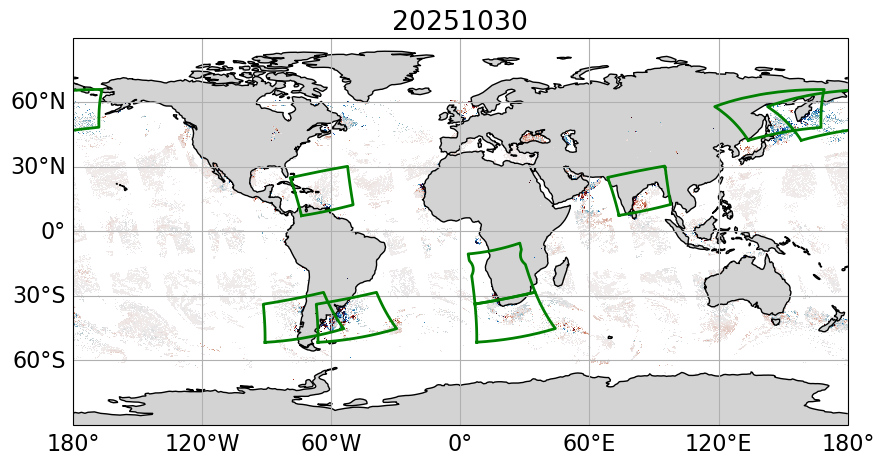

In [8]:
def plot_save_TC_l2(l2_data_paths, save_path, l3_bboxes, granule_bbox_pixel_counts, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save overlays of BGC L2 granules with bounding boxes.

    Parameters
    ----------
    l2_data_paths : list
        List of tuples, each containing file paths for a granule (e.g., (SFREFL_path, BGC_path)).
    save_path : str
        Directory to save figures.
    var_name : str
        Variable name to plot from BGC file.
    l3_bboxes : list
        List of bounding boxes for overlay.
    granule_bbox_pixel_counts : dict
        Mapping of path to bbox pixel counts.
    vmin, vmax, cmap, log_scale : plotting options
    show_fig : bool
        If True, display the figure.
    figsave : bool
        If True, save the figure to disk.
    dpi : int
        Resolution of saved figure.

    Returns
    -------
    None
    """
    #Status of TC plotting
    print(f"Generating {len(l2_data_paths)} true color plots of identified L2 granules...")

    for i, path in enumerate(l2_data_paths):
        try:
            sref_idx = [j for j, p in enumerate(path) if 'SFREFL' in str(p)][0]
        except IndexError:
            print(f"Could not find SFREFL or BGC in path tuple: {path}")
            continue

        fig, ax = plot_setup(map_props(path[sref_idx]))
        plot_rgb_from_path(path[sref_idx], ax)
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)
        
        if figsave:
            # Extract date_time from filename, fallback to index if not found
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(save_path, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f"{date_time}_TC.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")
            if show_fig:
                plt.show()
        else:
            if show_fig:
                plt.show()
        plt.close()

def plot_save_BGC_l2_overlay(l2_data_paths, save_path, var_name, l3_bboxes, granule_bbox_pixel_counts, vmin=None, vmax=None, cmap=cmocean.cm.haline, log_scale=True, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save overlays of BGC L2 granules with bounding boxes.

    Parameters
    ----------
    l2_data_paths : list
        List of tuples, each containing file paths for a granule (e.g., (SFREFL_path, BGC_path)).
    save_path : str
        Directory to save figures.
    var_name : str
        Variable name to plot from BGC file.
    l3_bboxes : list
        List of bounding boxes for overlay.
    granule_bbox_pixel_counts : dict
        Mapping of path to bbox pixel counts.
    vmin, vmax, cmap, log_scale : plotting options
    show_fig : bool
        If True, display the figure.
    figsave : bool
        If True, save the figure to disk.
    dpi : int
        Resolution of saved figure.

    Returns
    -------
    None
    """
    # Status of BGC plotting
    print(f"Generating {len(l2_data_paths)} {var_name} plots of identified L2 granules...")

    for i, path in enumerate(l2_data_paths):
        try:
            sref_idx = [j for j, p in enumerate(path) if 'SFREFL' in str(p)][0]
            bgc_idx = [j for j, p in enumerate(path) if 'BGC' in str(p)][0]
        except IndexError:
            print(f"Could not find SFREFL or BGC in path tuple: {path}")
            continue

        fig, ax = plot_setup(map_props(path[sref_idx]))
        plot_rgb_from_path(path[sref_idx], ax)
        plot_var_from_path(path[bgc_idx], var_name, ax, vmin=vmin, vmax=vmax, cmap=cmap, log_scale=log_scale)
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)
        
        if figsave:
            # Extract date_time from filename, fallback to index if not found
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(save_path, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f"{date_time}_{var_name}_overlay.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")
            if show_fig:
                plt.show()
        else:
            if show_fig:
                plt.show()
        plt.close()

def plot_save_AOP_l2_overlay(l2_data_paths, save_path, var_name, l3_bboxes, granule_bbox_pixel_counts, vmin=None, vmax=None, cmap=cmocean.cm.haline, log_scale=True, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save overlays of AOP L2 granules with bounding boxes.

    Parameters
    ----------
    l2_data_paths : list
        List of tuples, each containing file paths for a granule (e.g., (SFREFL_path, BGC_path)).
    save_path : str
        Directory to save figures.
    var_name : str
        Variable name to plot from BGC file.
    l3_bboxes : list
        List of bounding boxes for overlay.
    granule_bbox_pixel_counts : dict
        Mapping of path to bbox pixel counts.
    vmin, vmax, cmap, log_scale : plotting options
    show_fig : bool
        If True, display the figure.
    figsave : bool
        If True, save the figure to disk.
    dpi : int
        Resolution of saved figure.

    Returns
    -------
    None
    """
    # Status of AOP plotting
    print(f"Generating {len(l2_data_paths)} {var_name} plots of identified L2 granules...")

    for i, path in enumerate(l2_data_paths):
        try:
            sref_idx = [j for j, p in enumerate(path) if 'SFREFL' in str(p)][0]
            aop_idx = [j for j, p in enumerate(path) if 'AOP' in str(p)][0]
        except IndexError:
            print(f"Could not find SFREFL or AOP in path tuple: {path}")
            continue

        fig, ax = plot_setup(map_props(path[sref_idx]))
        plot_rgb_from_path(path[sref_idx], ax)
        if var_name == 'avw':
            cmap = generate_colormap(min_wavelength=400, max_wavelength=700, num_colors=256)
        plot_var_from_path(path[aop_idx], var_name, ax, vmin=vmin, vmax=vmax, cmap=cmap, log_scale=log_scale)
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)
        
        if figsave:
            # Extract date_time from filename, fallback to index if not found
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(save_path, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f"{date_time}_{var_name}_overlay.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")
            if show_fig:
                plt.show()
        else:
            if show_fig:
                plt.show()
        plt.close()

def plot_setup(props):
    """
    Set up a Cartopy map figure and axis with appropriate projection and aspect ratio.

    This function creates a matplotlib figure and Cartopy axis for plotting geospatial data.
    The projection is chosen based on whether the data crosses the dateline. The map is
    decorated with land, ocean, and coastline features, and gridlines are added.

    Parameters
    ----------
    props : dict
        Dictionary containing map properties, typically from `map_props()`, with keys:
            'flag_crossdateline' : bool
                Whether the longitude range crosses the dateline.
            'lon_range' : float
                Range of longitudes (degrees).
            'lat_range' : float
                Range of latitudes (degrees).

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created matplotlib figure.
    ax : matplotlib.axes._subplots.AxesSubplot
        The created Cartopy axis for plotting.

    Example
    -------
    >>> props = map_props("granule.nc")
    >>> fig, ax = plot_setup(props)
    """
    if props["flag_crossdateline"]:
        #fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
        #fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.Orthographic(central_longitude=180)})
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.Orthographic(central_latitude=props["meanlat"], central_longitude=props["meanlon"])})
    else:
        #fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        #fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.NorthPolarStereo()})
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.Orthographic(central_latitude=props["meanlat"], central_longitude=props["meanlon"])})


    # Add map features for context
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
    return fig, ax

def map_props(path):
    """
    Extract map properties from a dataset for plotting.

    Opens a dataset from the given path, merges all groups, and computes:
      - Longitude and latitude ranges (in 0-360 and 0-180)
      - Whether the data crosses the dateline (for map projection selection)

    Parameters
    ----------
    path : str or Path
        Path to the dataset file (NetCDF, Zarr, etc.).

    Returns
    -------
    props : dict
        Dictionary with:
            'flag_crossdateline' : bool
                True if the longitude range crosses the dateline (difference > 180°).
            'lon_range' : float
                Range of longitudes (max - min).
            'lat_range' : float
                Range of latitudes (max - min).

    Example
    -------
    >>> props = map_props("granule.nc")
    """
    dt = xr.open_datatree(path, decode_timedelta=True)  # Open the downloaded data as an xarray DataTree
    ds = xr.merge(dt.to_dict().values())  # Merge all datasets in the DataTree into a single xarray Dataset
    ds = ds.set_coords(("longitude", "latitude"))  # Set longitude and latitude as coordinates

    # Convert longitude and latitude to 0-360 and 0-180 for range calculation
    lons = ds['longitude'].values % 360
    lats = ds['latitude'].values % 180

    lonrange = float(np.nanmax(lons) - np.nanmin(lons))
    latrange = float(np.nanmax(lats) - np.nanmin(lats))

    # Determine if longitudes cross the dateline
    flag_crossdateline = (ds['longitude'].max() - ds['longitude'].min()) > 180

    # Store outputs in a dictionary
    props = {
        "flag_crossdateline": flag_crossdateline,
        "lon_range": lonrange,
        "lat_range": latrange,
        "meanlon": float(np.nanmean(ds['longitude'].values)),
        "meanlat": float(np.nanmean(ds['latitude'].values))
    }

    return props

def plot_rgb_from_path(path, ax, savefig=False, plot_path=None, dpi=100):
    """
    Plot an RGB composite from hyperspectral reflectance data on a Cartopy axis.

    This function opens a dataset, extracts the reflectance at three wavelengths
    (610, 555, 465 nm) to create an RGB image, enhances it, and plots it using pcolormesh
    on the provided Cartopy axis.

    Parameters
    ----------
    path : str or Path
        Path to the dataset file containing 'rhos' (reflectance) and coordinates.
    ax : matplotlib.axes.Axes
        Cartopy axis on which to plot the RGB image.
    savefig : bool, optional
        If True, save the figure to disk (default: False).
    plot_path : str or Path, optional
        Path to save the figure if savefig is True.
    dpi : int, optional
        Resolution of saved figure (default: 100).

    Returns
    -------
    plot : matplotlib.collections.QuadMesh
        The pcolormesh plot object.

    Example
    -------
    >>> fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    >>> plot_rgb_from_path("granule.nc", ax)
    """
    dt = xr.open_datatree(path, decode_timedelta=True)  # Open the downloaded data as an xarray DataTree
    ds = xr.merge(dt.to_dict().values())  # Merge all datasets in the DataTree into a single xarray Dataset
    ds = ds.set_coords(("longitude", "latitude"))  # Set longitude and latitude as coordinates
    
    # Select reflectance at RGB wavelengths (610, 555, 465 nm)
    rhos_rgb = ds['rhos'].sel(wavelength_3d=[610, 555, 465], method='nearest')
    rgb = enhance(rhos_rgb,show_hist=False)  # Enhance the RGB composite (user-defined function)

    # Plot the RGB image using pcolormesh
    plot = ax.pcolormesh(
        rgb["longitude"],
        rgb["latitude"],
        rgb,
        shading="nearest",
        rasterized=True,
        transform=ccrs.PlateCarree()
    )

    # Optionally save the figure
    if savefig and plot_path is not None:
        plt.savefig(plot_path, dpi=dpi)

    return plot

def enhance(rgb, scale = 0.01, vmin = 0.01, vmax = 1.04, gamma=0.95, contrast=1.2, brightness=1.1, sharpness=2, saturation=1.1, show_hist=False):
    """The SeaDAS recipe for RGB images from Ocean Color missions.

    Args:
        rgb: a data array with three dimensions, having 3 or 4 bands in the third dimension
        scale: scale value for the log transform
        vmin: minimum pixel value for the image
        vmax: maximum pixel value for the image
        gamma: exponential factor for gamma correction
        contrast: amount of pixel value differentiation 
        brightness: pixel values (intensity)
        sharpness: amount of detail
        saturation: color intensity

    Returns:
       a transformed data array better for RGB display
    """
    rgb = rgb.where(rgb > 0)
    rgb = np.log(rgb / scale) / np.log(1 / scale)
    rgb = rgb.where(rgb >= vmin, vmin)
    rgb = rgb.where(rgb <= vmax, vmax)    

    rgb_min = rgb.min(("number_of_lines", "pixels_per_line"))
    rgb_max = rgb.max(("number_of_lines", "pixels_per_line"))
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
    rgb = rgb * gamma
    img = rgb * 255
    img = img.where(img.notnull(), 0).astype("uint8")
    img = Image.fromarray(img.data)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(brightness)
    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(sharpness)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(saturation)
    rgb[:] = np.array(img) / 255

    # Restore minimum brightness to originally-valid pixels that became too dark
    # This prevents valid nonzero pixels from collapsing to [0,0,0]
    rgb = rgb.where(rgb >= vmin, vmin)

    if show_hist:
        vals = rgb.values.reshape(-1, rgb.shape[2])   # (Npix, 3)
        valid = ~np.any(np.isnan(vals), axis=1)
        vals_valid = vals[valid]
        if vals_valid.size:
            wls = [610, 555, 465]
            fig_h, ax_h = plt.subplots(1, 1, figsize=(5, 3))
            colors = ['r', 'g', 'b']
            bins = 100
            for b, color, wl in zip(range(vals_valid.shape[1]), colors, wls):
                ax_h.hist(vals_valid[:, b], bins=bins, range=(0, 1), color=color, alpha=0.5, label=f"{int(wl)} nm")
            ax_h.set_xlabel("Enhanced Reflectance")
            ax_h.set_ylabel("Pixel count")
            ax_h.legend(fontsize=9)
            ax_h.set_title("Enhanced RGB histograms")
            fig_h.tight_layout()

    return rgb

def plot_var_from_path(path, var_str, ax, cmap=cmocean.cm.haline, vmin=None, vmax=None, log_scale=True, output_path=None, dpi=100):
    """
    Plot a variable from an xarray.Dataset on a Cartopy axis with colorbar.

    Opens a dataset, extracts the specified variable, masks non-positive values (for log scale),
    and plots it using pcolormesh on the provided Cartopy axis. Adds a colorbar with units.

    Parameters
    ----------
    path : str or Path
        Path to the dataset file.
    var_str : str
        Name of the variable to plot.
    ax : matplotlib.axes.Axes
        Cartopy axis on which to plot the data.
    cmap : matplotlib.colors.Colormap, optional
        Colormap to use for the plot (default: cmocean.cm.haline).
    vmin : float, optional
        Minimum value for color normalization. If None, uses data minimum.
    vmax : float, optional
        Maximum value for color normalization. If None, uses data maximum.
    log_scale : bool, optional
        If True, use logarithmic color normalization (default: True).
    output_path : str or Path, optional
        If provided, save the figure to this path.
    dpi : int, optional
        Resolution of saved figure (default: 100).

    Returns
    -------
    mesh : matplotlib.collections.QuadMesh
        The pcolormesh plot object.
    cbar : matplotlib.colorbar.Colorbar
        The colorbar object.

    Example
    -------
    >>> fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    >>> plot_var_from_path("granule.nc", "chlor_a", ax)
    """
    from mpl_toolkits.axes_grid1 import make_axes_locatable  # For colorbar placement

    dt = xr.open_datatree(path, decode_timedelta=True)  # Open the downloaded data as an xarray DataTree
    ds = xr.merge(dt.to_dict().values())  # Merge all datasets in the DataTree into a single xarray Dataset
    ds = ds.set_coords(("longitude", "latitude"))  # Set longitude and latitude as coordinates

    data = ds[var_str]
    data = data.where(data > 0)  # Mask out non-positive values for log scale
    lon = ds['longitude']
    lat = ds['latitude']

    if vmin is None:
        vmin = np.nanmin(data.values)

    if vmax is None:
        vmax = np.nanmax(data.values)

    norm = LogNorm(vmin=vmin, vmax=vmax) if log_scale else None

    # Use pcolormesh for Cartopy axes and 2D coordinates
    if log_scale:
        mesh = ax.pcolormesh(lon, lat, data, cmap=cmap, norm=norm, shading='auto', transform=ccrs.PlateCarree())
    else:
        mesh = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto', transform=ccrs.PlateCarree())
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="2.5%", pad=0.5, axes_class=plt.Axes)
    cbar = plt.colorbar(mesh, cax=cax, orientation='horizontal')
    # Add variable name and units to colorbar label if available
    units = data.attrs['units'] if 'units' in data.attrs else ''
    cbar.set_label(f"{data.name} [{units}]" if units else data.name)

    # Uncomment to add title to figure for troubleshooting
    # Annotate with granule date/time if available
    # match = re.search(r'\.(\d{8}T\d{6})\.', ds.product_name)
    # if match:
    #     date_time = match.group(1)
    #     ax.set_title(date_time, fontsize=16)

    if output_path:
        plt.savefig(output_path, dpi=dpi)

    return mesh, cbar

def add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts):
    """
    Add bounding boxes to the plot for the given granule path.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The Cartopy axis to add bounding boxes to.
    path : tuple or str
        The key for granule_bbox_pixel_counts, typically the granule path.
    l3_bboxes : list of tuple
        List of bounding boxes (min_lon, min_lat, max_lon, max_lat).
    granule_bbox_pixel_counts : dict
        Dictionary mapping path to {bbox_idx: numpixels}.
        Here, `numpixels` is the number of valid pixels within the corresponding bounding box
        for the given granule. It is computed by `count_valid_pixels()` in detection_util_MK.py,
        which counts the number of pixels in the granule that fall within each bounding box and
        meet the validity criteria (e.g., not masked or NaN).

    Returns
    -------
    None

    Notes
    -----
    Only bounding boxes with numpixels > 0 (i.e., containing valid data for the granule)
    are plotted. Optionally, the pixel count can be annotated on the plot.
    """
    import matplotlib.patches as patches       # Drawing shapes (e.g., rectangles)

    for bbox_idx, numpixels in granule_bbox_pixel_counts[path].items():
        if numpixels > 5000:
            min_lon, min_lat, max_lon, max_lat = l3_bboxes[bbox_idx]
            # Handle dateline crossing
            if min_lon > max_lon:
                width1 = 180 - min_lon if max_lon < 0 else 360 - min_lon
                rect1 = patches.Rectangle(
                    (min_lon, min_lat), width1, max_lat - min_lat,
                    linewidth=1, edgecolor='red', facecolor='none',
                    transform=ccrs.PlateCarree()
                )
                ax.add_patch(rect1)
                width2 = max_lon - (-180) if max_lon < 0 else max_lon - 0
                rect2 = patches.Rectangle(
                    ((-180 if max_lon < 0 else 0), min_lat), width2, max_lat - min_lat,
                    linewidth=1, edgecolor='red', facecolor='none',
                    transform=ccrs.PlateCarree()
                )
                ax.add_patch(rect2)
            else:
                width = max_lon - min_lon
                height = max_lat - min_lat
                rect = patches.Rectangle(
                    (min_lon, min_lat), width, height,
                    linewidth=1, edgecolor='red', facecolor='none',
                    transform=ccrs.PlateCarree()
                )
                ax.add_patch(rect)
            # Optionally annotate with pixel count
            # ax.text(
            #     (min_lon + max_lon) / 2, (min_lat + max_lat) / 2,
            #     str(numpixels),
            #     color='red', fontsize=8, ha='center', va='center',
            #     transform=ccrs.PlateCarree()
            # )
            # print(f"Plotted bbox {bbox_idx} with {numpixels} valid pixels.")

# functions to make wavelength-accurate avw colormap, no need to change
def wavelength_to_rgb(wavelength):
    """
    Convert a wavelength in the range 380-750 nm to an RGB color.
    Source: http://www.had2know.com/technology/rgb-color-wavelength-conversion.html
    """
    gamma = 0.8
    intensity_max = 255

    if (wavelength >= 380) and (wavelength < 440):
        R = -(wavelength - 440) / (440 - 380)
        G = 0.0
        B = 1.0
    elif (wavelength >= 440) and (wavelength < 490):
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif (wavelength >= 490) and (wavelength < 510):
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif (wavelength >= 510) and (wavelength < 580):
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif (wavelength >= 580) and (wavelength < 645):
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif (wavelength >= 645) and (wavelength <= 750):
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R = G = B = 0.0

    # Adjust intensity and apply gamma correction
    R = round(intensity_max * (R**gamma))/255
    G = round(intensity_max * (G**gamma))/255
    B = round(intensity_max * (B**gamma))/255

    return (R, G, B)

def generate_colormap(min_wavelength=380, max_wavelength=750, num_colors=256):
    """
    Generates a colormap for wavelengths between `min_wavelength` and `max_wavelength`.
    """
    # Ensure the wavelengths are within the visible range
    min_wavelength = max(min_wavelength, 380)
    max_wavelength = min(max_wavelength, 750)

    # Generate a list of wavelengths between min and max
    wavelengths = np.linspace(min_wavelength, max_wavelength, num_colors)
    #print(wavelengths)
    # Convert wavelengths to RGB colors
    colors = [wavelength_to_rgb(w) for w in wavelengths]
    #print(colors)
    # Create a LinearSegmentedColormap using the RGB colors
    cmap_ = LinearSegmentedColormap.from_list("wavelength_cmap", colors, num_colors)
    return cmap_

def plot_granule_outline(l2_data_paths, save_path, show_fig=True, figsave=False, dpi=100):
    """
    Plot the outline of each L2 granule on a map, handling dateline crossing.

    For each granule in l2_data_paths, this function:
      - Opens the SFREFL file and extracts longitude/latitude arrays.
      - Computes the outline of the granule by tracing its edges.
      - Handles dateline crossing by splitting the outline at longitude jumps >180°.
      - Plots the outline as a red line on an Orthographic map centered on the granule.
      - Optionally annotates the plot with the granule's date/time.
      - Saves each plot to save_path if figsave is True.

    Parameters
    ----------
    l2_data_paths: str
        Path to the L2 granule data file.
    save_path: str
        Directory to save figures.
    show_fig: bool, optional
        If True, display the figure (default: True).
    figsave: bool, optional
        If True, save the figure to disk (default: False).
    dpi: int, optional
        Resolution of saved figure (default: 100).

    Returns
    -------
    None
    """
    for i, path in enumerate(l2_data_paths):
        try:
            sref_idx = [j for j, p in enumerate(path) if 'SFREFL' in str(p)][0]
        except IndexError:
            print(f"Could not find SFREFL in path tuple: {path}")
            continue

        # Open the SFREFL file and extract coordinates
        dt = xr.open_datatree(path[sref_idx], decode_timedelta=True)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        # Compute mean longitude/latitude for map centering
        meanlon = float(np.mean(ds['longitude'].values))
        meanlat = float(np.mean(ds['latitude'].values))

        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.Orthographic(central_longitude=meanlon, central_latitude=meanlat)}
        )

        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
        ax.gridlines(draw_labels={"left": "y", "bottom": "x"})

        # Extract longitude and latitude arrays
        lons = ds['longitude'].values
        lats = ds['latitude'].values

        # Trace the outline of the granule (clockwise)
        edge_lon = lons[0, :]
        edge_lat = lats[0, :]
        edge_lon = np.concatenate([edge_lon, lons[1:, -1]])
        edge_lat = np.concatenate([edge_lat, lats[1:, -1]])
        edge_lon = np.concatenate([edge_lon, lons[-1, ::-1]])
        edge_lat = np.concatenate([edge_lat, lats[-1, ::-1]])
        edge_lon = np.concatenate([edge_lon, lons[-2::-1, 0]])
        edge_lat = np.concatenate([edge_lat, lats[-2::-1, 0]])

        # Convert longitudes to [-180, 180] for PlateCarree
        edge_lon = ((edge_lon + 180) % 360) - 180

        # Split outline at dateline crossing (jumps >180°)
        jump = np.abs(np.diff(edge_lon))
        split_idx = np.where(jump > 180)[0] + 1
        if split_idx.size > 0:
            edge_lon_plot = np.split(edge_lon, split_idx)
            edge_lat_plot = np.split(edge_lat, split_idx)
        else:
            edge_lon_plot = [edge_lon]
            edge_lat_plot = [edge_lat]

        # Plot each segment separately
        for seg_lon, seg_lat in zip(edge_lon_plot, edge_lat_plot):
            ax.plot(seg_lon, seg_lat, color='green', linewidth=2, transform=ccrs.PlateCarree())

        # Annotate with granule date/time if available
        match = re.search(r'\.(\d{8}T\d{6})\.', ds.product_name)
        if match:
            date_time = match.group(1)
            top_lon = np.mean(lons)
            top_lat = np.max(lats)
            ax.text(
                top_lon, top_lat + 1, date_time,
                ha='center', va='bottom',
                fontsize=14,
                color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='square,pad=0.2'),
                transform=ccrs.PlateCarree(),
                zorder=10
            )

        ax.set_global()

        # Save or show figure
        if figsave:
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(save_path, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f"{date_time}_outline.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            if show_fig:
                plt.show()
        else:
            if show_fig:
                plt.show()
        plt.close()

def plot_L3_anomaly_on_L2_granules(l3_ds_target, l3_ds_window, l3_bboxes, granule_bbox_pixel_counts, l2_data_paths, savepath, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save L3 chlorophyll-a anomaly overlays on L2 granule extents, with bounding boxes.

    Parameters
    ----------
    l3_ds_target : xarray.Dataset
        Target day L3 dataset.
    l3_ds_window : xarray.Dataset
        30-day window L3 dataset.
    l3_bboxes : list of tuple
        List of bounding boxes (min_lon, min_lat, max_lon, max_lat).
    granule_bbox_pixel_counts : dict
        Dictionary mapping each granule path to a dict of {bbox_idx: valid_pixel_count}.
    l2_data_paths : list
        List of L2 data path tuples.
    savepath : str
        Directory to save figures.
    show_fig : bool, optional
        If True, display the figures (default: True).
    figsave : bool, optional
        If True, save the figures to disk (default: False).
    dpi : int, optional
        Resolution of saved figures (default: 100).

    Returns
    -------
    None
    """
    # Status of chl-a anomaly per granule plotting
    print(f"Generating chlorophyll-a anomaly plots of identified L2 granules...")

    # Compute chlorophyll-a anomaly
    chl_anomaly = l3_ds_target['chlor_a'].mean('time') - l3_ds_window['chlor_a'].mean('time')
    date_str = l3_ds_target.product_name.split('.')[1]

    # Loop over L2 granules to plot anomaly overlays
    for i, path in enumerate(l2_data_paths):
        try:
            bgc_idx = [j for j, p in enumerate(path) if 'BGC' in str(p)][0]
        except IndexError:
            print(f"Could not find BGC in path tuple: {path}")
            continue

        # Open the BGC file and extract coordinates
        dt = xr.open_datatree(path[bgc_idx], decode_timedelta=True)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        # Plot L3 anomaly and L2 granule outline
        ax = plot_L3_anomaly_per_L2_granule(
            chl_anomaly,
            ds,
            cmap=cmocean.cm.balance,
            clabel='Chlorophyll-a Anomaly [mg/m^3]',
            vmin=-1, vmax=1,
            log_scale=False
        )
        
        #Add map features for context
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='white')

        # Overlay bounding boxes for this granule
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)

        if figsave:
            # Extract date_time from filename, fallback to index if not found
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(savepath, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname =  f'{date_time}_L3_Chl_Anomaly_L2gran_bboxes.png'
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")
            if show_fig:
                plt.show()
        else:
            if show_fig:
                plt.show()
        plt.close()

def plot_L3_anomaly_per_L2_granule(dataarray, l2_dataset, title=None, cmap=cmocean.cm.haline, clabel=None, vmin=None, vmax=None, log_scale=True, output_path=None, dpi=100):
    """
    Plot an xarray.DataArray (e.g., L3 anomaly) over the spatial extent of an L2 granule.

    Parameters
    ----------
    dataarray : xarray.DataArray
        The data to plot (e.g., L3 anomaly).
    l2_dataset : xarray.Dataset
        The L2 dataset providing longitude/latitude for extent and outline.
    title : str, optional
        Title for the plot.
    cmap : matplotlib Colormap, optional
        Colormap for the plot.
    clabel : str, optional
        Label for the colorbar.
    vmin, vmax : float, optional
        Color scale limits.
    log_scale : bool, optional
        If True, use logarithmic color normalization.
    output_path : str, optional
        If provided, save the figure to this path.
    dpi : int, optional
        Resolution of saved figure.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The created axis.

    """
    # Compute average map center
    meanlon = float(np.nanmean(l2_dataset['longitude'].values))
    meanlat = float(np.nanmean(l2_dataset['latitude'].values))

    # Determine longitude/latitude extent, handling dateline crossing
    lons = l2_dataset['longitude'].values
    lats = l2_dataset['latitude'].values
    min_lon = np.nanmin(lons)
    max_lon = np.nanmax(lons)
    min_lat = np.nanmin(lats)
    max_lat = np.nanmax(lats)
    if max_lon - min_lon > 180:
        lon_360 = lons % 360
        lon_ex_min = np.nanmin(lon_360)
        lon_ex_max = np.nanmax(lon_360)
    else:
        lon_ex_min = min_lon
        lon_ex_max = max_lon

    # Set up figure and axis
    fig, ax = plt.subplots(
        figsize=(10, 8),
        subplot_kw={'projection': ccrs.Orthographic(central_longitude=meanlon, central_latitude=meanlat)}
    )
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
    #ax.set_extent([lon_ex_min, lon_ex_max, min_lat, max_lat], crs=ccrs.PlateCarree())

    if title:
        ax.set_title(title)

    # Set color scale limits
    if vmin is None:
        vmin = np.nanmin(dataarray.values)
    if vmax is None:
        vmax = np.nanmax(dataarray.values)
    norm = LogNorm(vmin=vmin, vmax=vmax) if log_scale else None

    # Restrict dataarray to L2 granule extent for efficiency
    dataarray = dataarray.sel(lon=slice(min_lon, max_lon), lat=slice(max_lat, min_lat))

    # Plot the data
    plot = ax.pcolormesh(
        dataarray["lon"],
        dataarray["lat"],
        dataarray,
        cmap=cmap,
        norm=norm,
        shading='auto',
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    # Add colorbar
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05)
    if clabel:
        cbar.set_label(clabel)

    # Draw granule outline (clockwise)
    edge_lon = np.concatenate([lons[0, :], lons[1:, -1], lons[-1, ::-1], lons[-2::-1, 0]])
    edge_lat = np.concatenate([lats[0, :], lats[1:, -1], lats[-1, ::-1], lats[-2::-1, 0]])

    # Convert longitudes to [-180, 180] for PlateCarree
    edge_lon = ((edge_lon + 180) % 360) - 180
    # Split outline at dateline crossing
    jump = np.abs(np.diff(edge_lon))
    split_idx = np.where(jump > 180)[0] + 1
    edge_lon_plot = np.split(edge_lon, split_idx) if split_idx.size > 0 else [edge_lon]
    edge_lat_plot = np.split(edge_lat, split_idx) if split_idx.size > 0 else [edge_lat]
    for seg_lon, seg_lat in zip(edge_lon_plot, edge_lat_plot):
        ax.plot(seg_lon, seg_lat, color='green', linewidth=2, transform=ccrs.PlateCarree())

    # Save if requested
    if output_path:
        plt.savefig(output_path, dpi=dpi)

    return ax


def plot_L2_granule_outlines(l3_ds_target, l3_ds_window, l2_data_paths_filt, save_path, show_fig=True, figsave=False, dpi=100):
    """
    Plot L2 granule outlines overlaid on a global chlorophyll-a anomaly map.

    This function creates a global map showing the L3 chlorophyll-a anomaly as a background,
    then overlays the outlines of all filtered L2 granules. Dateline crossing is handled by
    splitting granule outlines at longitude jumps >180°. The resulting map provides a
    comprehensive view of L2 granule coverage relative to identified chl-a anomalies.

    Parameters
    ----------
    l3_ds_target : xarray.Dataset
        Target day L3 chlorophyll-a dataset.
    l3_ds_window : xarray.Dataset
        30-day window L3 chlorophyll-a dataset (used to compute anomaly baseline).
    l2_data_paths_filt : list of tuple
        List of filtered L2 granule file path tuples. Each tuple contains paths for a scene
        (e.g., (SFREFL_path, BGC_path, AOP_path)). The BGC file (typically at index 1)
        is used to extract coordinate information.
    save_path : str
        Directory to save the output figure. Created if it does not exist.
    show_fig : bool, optional
        If True, display the figure interactively (default: True).
    figsave : bool, optional
        If True, save the figure to disk as PNG (default: False).
    dpi : int, optional
        Resolution of saved figure in dots per inch (default: 100).

    Returns
    -------
    None

    Notes
    -----
    - Chlorophyll-a anomaly is computed as: target_chl_a - window_chl_a.
    - Anomaly range is fixed at [-1, 1] mg/m³ for consistent visualization.
    - Granule outlines are traced clockwise (top → right → bottom → left).
    - Outlines crossing the dateline are split into segments for proper rendering on PlateCarree projection.
    - Output filename includes the target date stamp extracted from the L3 dataset.

    Raises
    ------
    IndexError
        If a BGC file is not found in a path tuple (error is printed and granule is skipped).
    AttributeError
        If l3_ds_target lacks a 'product_name' attribute (date extraction will fail).

    Example
    -------
    >>> plot_L2_granule_outlines(
    ...     l3_ds_target, l3_ds_window, l2_data_paths_filt,
    ...     save_path='./figures/20250916/png/',
    ...     show_fig=False, figsave=True, dpi=150
    ... )

    See Also
    --------
    plot_granule_outline : Plot individual granule outlines on separate Orthographic maps.
    plot_L3_anomaly_on_L2_granules : Plot L3 anomaly restricted to L2 granule extents.
    """
    # Status message
    print(f"Generating world map of identified L2 granules...")

    # Compute chlorophyll-a anomaly
    chl_anomaly = l3_ds_target['chlor_a'].mean('time') - l3_ds_window['chlor_a'].mean('time')
    
    # Extract date string from L3 dataset product name (format: YYYYMMDD)
    try:
        date_str = l3_ds_target.product_name.split('.')[1]
    except (AttributeError, IndexError):
        date_str = "unknown_date"
        print(f"Warning: Could not extract date from product_name. Using '{date_str}'.")

    # ========== SET UP GLOBAL MAP ==========
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    # ========== PLOT BACKGROUND: CHL-A ANOMALY ==========
    chl_anomaly.plot(
        x="lon",
        y="lat",
        ax=ax,
        cmap=cmocean.cm.balance,
        extend="neither",
        robust=False,
        add_colorbar=False,
        vmin=-1,
        vmax=1,
        transform=ccrs.PlateCarree()
    )

    # ========== OVERLAY L2 GRANULE OUTLINES ==========
    for i, path in enumerate(l2_data_paths_filt):
        try:
            # Find the index of the BGC file in the path tuple
            bgc_idx = [j for j, p in enumerate(path) if 'BGC' in str(p)][0]
        except IndexError:
            print(f"Could not find BGC in path tuple: {path}")
            continue

        # Open the BGC file and extract coordinates
        dt = xr.open_datatree(path[bgc_idx], decode_timedelta=True)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        # Extract coordinate arrays
        lons = ds['longitude'].values
        lats = ds['latitude'].values

        # Trace the granule outline clockwise: top → right → bottom → left → top
        edge_lon = np.concatenate([lons[0, :], lons[1:, -1], lons[-1, ::-1], lons[-2::-1, 0]])
        edge_lat = np.concatenate([lats[0, :], lats[1:, -1], lats[-1, ::-1], lats[-2::-1, 0]])

        # Convert longitudes to [-180, 180] convention for PlateCarree projection
        edge_lon = ((edge_lon + 180) % 360) - 180

        # Handle dateline crossing: split outline at longitude jumps >180°
        jump = np.abs(np.diff(edge_lon))
        split_idx = np.where(jump > 180)[0] + 1
        edge_lon_plot = np.split(edge_lon, split_idx) if split_idx.size > 0 else [edge_lon]
        edge_lat_plot = np.split(edge_lat, split_idx) if split_idx.size > 0 else [edge_lat]

        # Plot each outline segment
        for seg_lon, seg_lat in zip(edge_lon_plot, edge_lat_plot):
            ax.plot(seg_lon, seg_lat, color='green', linewidth=2, transform=ccrs.PlateCarree())

    # ========== FINALIZE AND SAVE/SHOW ==========
    ax.set_title(date_str)

    if figsave:
        os.makedirs(save_path, exist_ok=True)
        output_file = os.path.join(save_path, f'L2_Grans_All_{date_str}.png')
        fig.savefig(output_file, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {output_file}")

    if show_fig:
        plt.show()

    plt.close(fig)

##############################################################################################################################################################
plot_L2_granule_outlines(l3_ds_target, l3_ds_window,l2_data_paths_filt, plot_path, show_fig=True, figsave=True)
# plot_granule_outline(l2_data_paths_filt, plot_path, show_fig=False, figsave=True)
#plot_L3_anomaly_on_L2_granules(l3_ds_target, l3_ds_window, l3_bboxes, granule_bbox_pixel_counts, [l2_data_paths_filt[-6]], plot_path, show_fig=True, figsave=True)
# plot_save_TC_l2(l2_data_paths_filt, plot_path, l3_bboxes, granule_bbox_pixel_counts, show_fig=False, figsave=True)
# plot_save_BGC_l2_overlay(l2_data_paths_filt, plot_path, 'chlor_a', l3_bboxes, granule_bbox_pixel_counts, cmap=cmocean.cm.algae, vmin=0.1, vmax=30, show_fig=False, figsave=True)
# plot_save_BGC_l2_overlay(l2_data_paths_filt, plot_path, 'poc', l3_bboxes, granule_bbox_pixel_counts, cmap=cmocean.cm.turbid, vmin=10, vmax=10000, show_fig=False, figsave=True)
# plot_save_BGC_l2_overlay(l2_data_paths_filt, plot_path, 'carbon_phyto', l3_bboxes, granule_bbox_pixel_counts, cmap=cmocean.cm.speed, vmin=10, vmax=1000, show_fig=False, figsave=True)
# plot_save_AOP_l2_overlay(l2_data_paths_filt, plot_path, 'avw', l3_bboxes, granule_bbox_pixel_counts, vmin=400, vmax=700, log_scale=False, show_fig=False, figsave=True)
# plot_save_AOP_l2_overlay(l2_data_paths_filt, plot_path, 'nflh', l3_bboxes, granule_bbox_pixel_counts, cmap=cmocean.cm.thermal, vmin=0, vmax=1, log_scale=False, show_fig=False, figsave=True)



## SST and SST Anomaly Plots

Generating 8 SST and SST anomaly plots of identified L2 granules using 0.25 deg GHRSST Level 4 (MUR25-JPL-L4-GLOB-v04.2) dataset. For more information please see: https://podaac.jpl.nasa.gov/dataset/MUR-JPL-L4-GLOB-v4.1...


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Figure saved to: ./figures/20251030/png/20251030T004525/20251030T004525_GHRSSTL4_SST_L2gran_bboxes.png


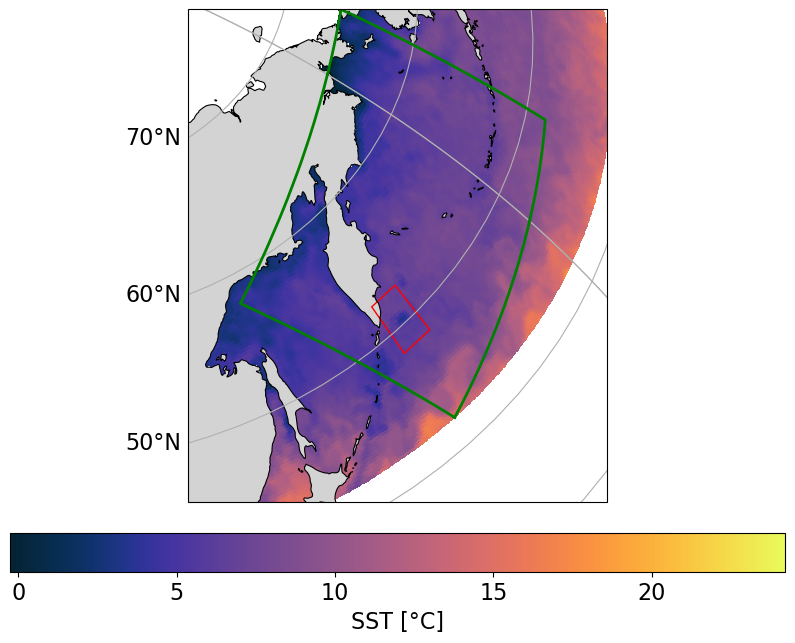

Figure saved to: ./figures/20251030/png/20251030T004525/20251030T004525_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


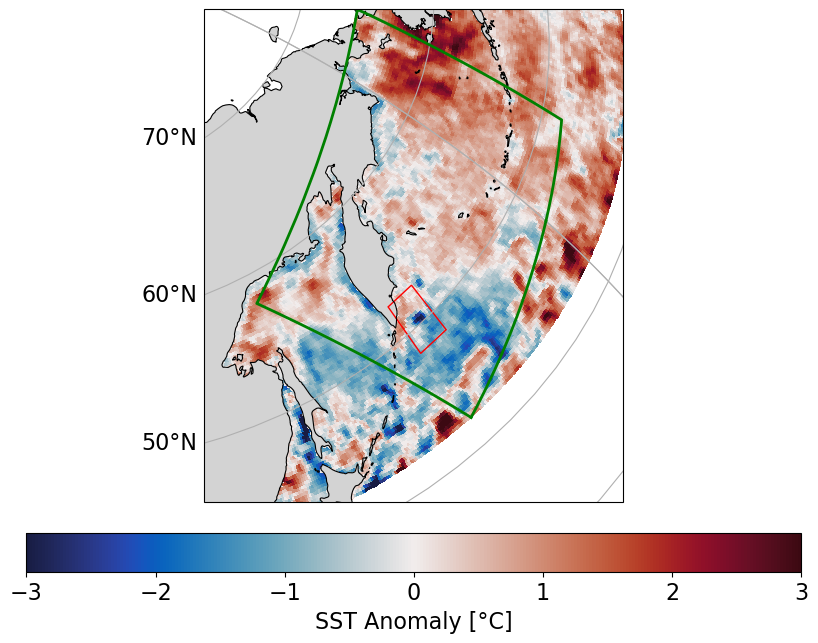

Figure saved to: ./figures/20251030/png/20251030T022345/20251030T022345_GHRSSTL4_SST_L2gran_bboxes.png


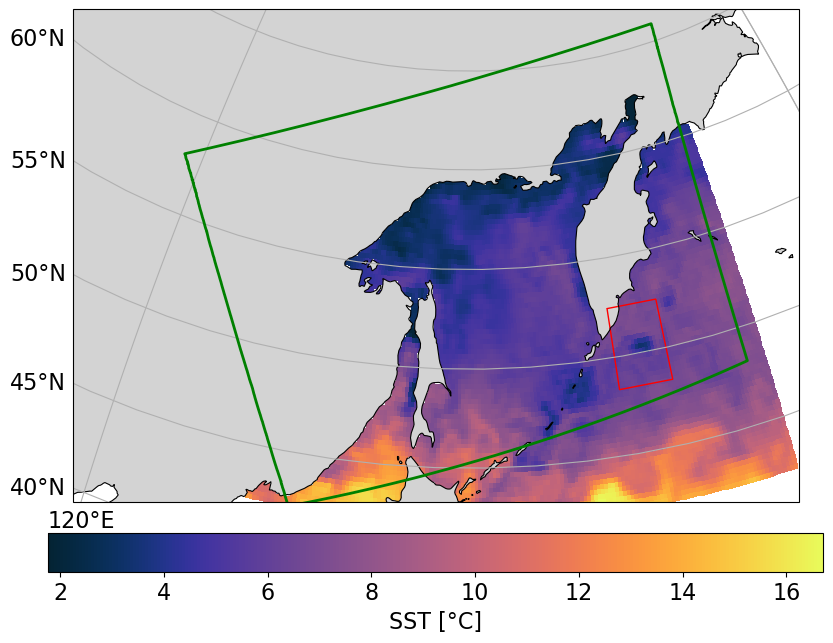

Figure saved to: ./figures/20251030/png/20251030T022345/20251030T022345_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


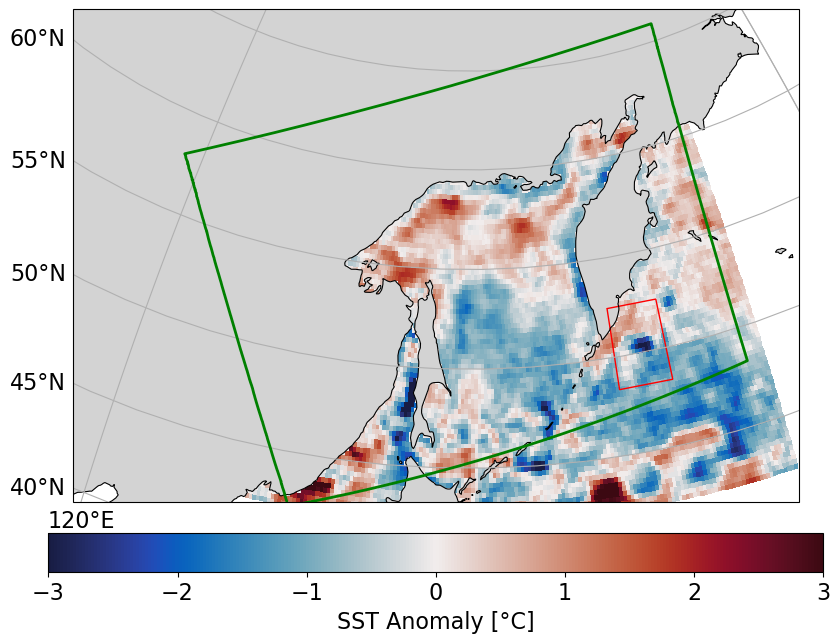

Figure saved to: ./figures/20251030/png/20251030T070844/20251030T070844_GHRSSTL4_SST_L2gran_bboxes.png


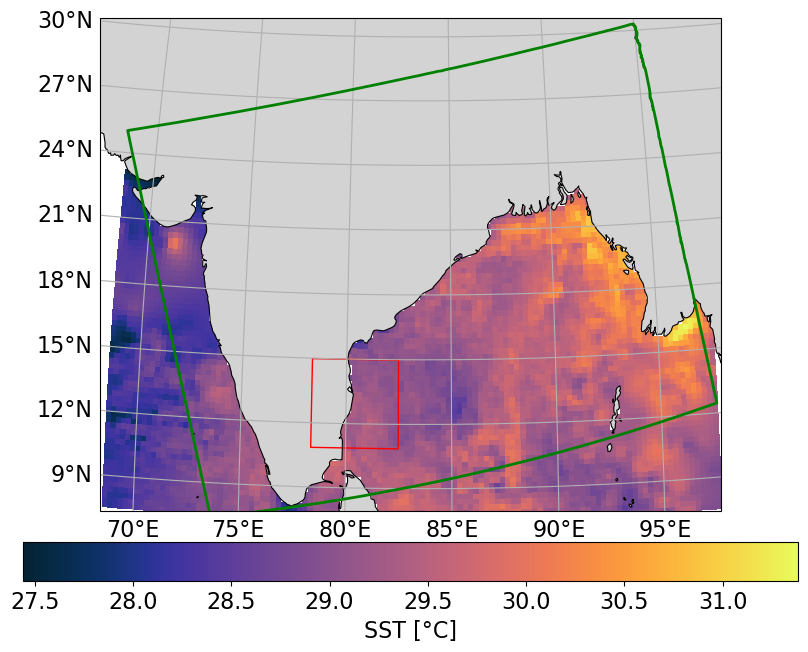

Figure saved to: ./figures/20251030/png/20251030T070844/20251030T070844_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


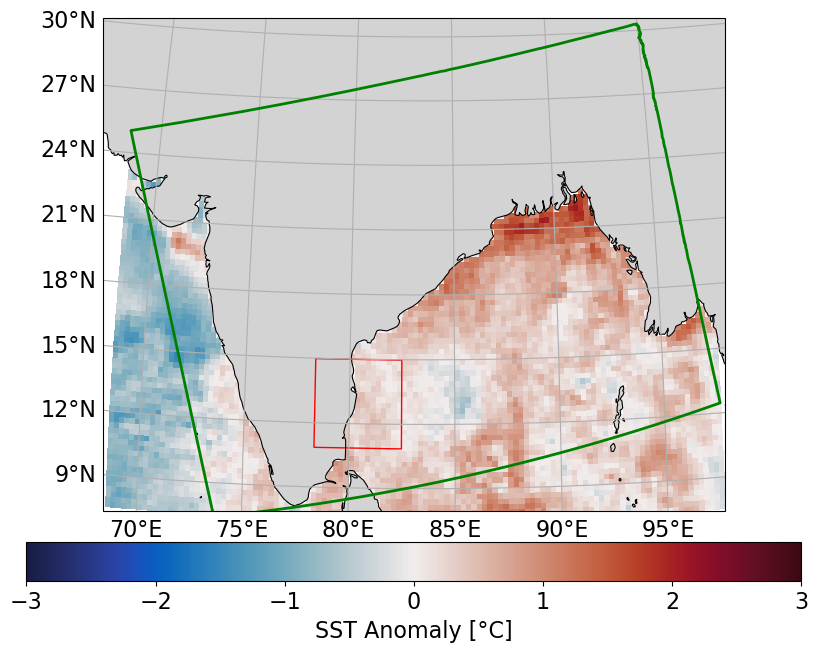

Figure saved to: ./figures/20251030/png/20251030T114843/20251030T114843_GHRSSTL4_SST_L2gran_bboxes.png


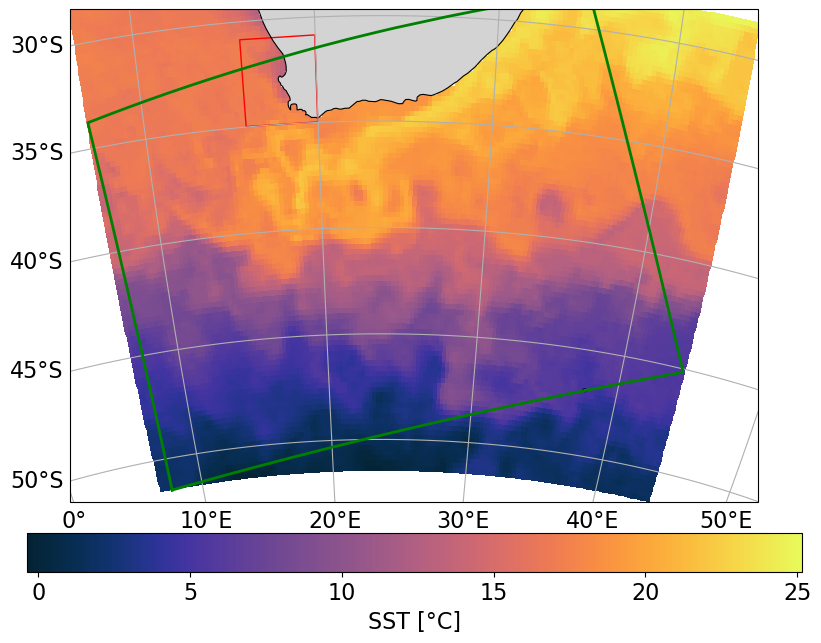

Figure saved to: ./figures/20251030/png/20251030T114843/20251030T114843_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


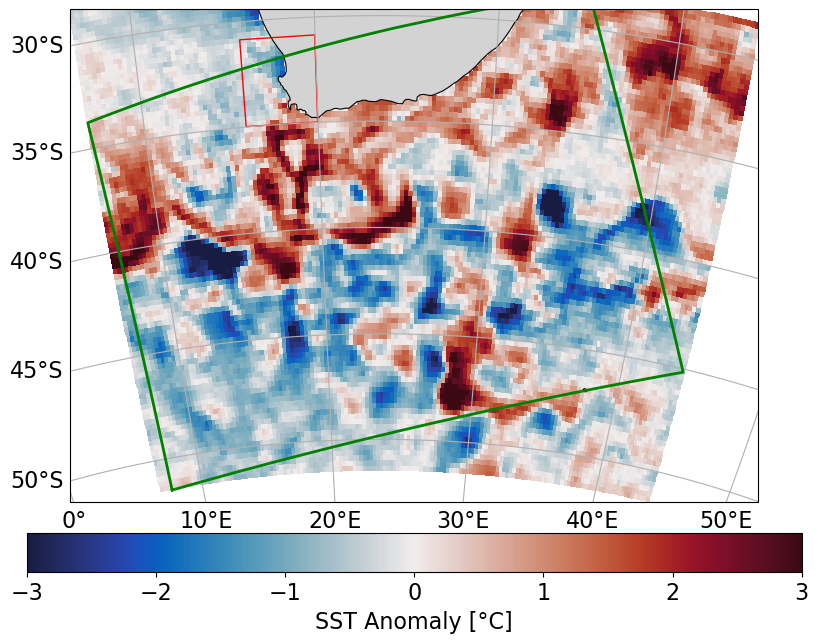

Figure saved to: ./figures/20251030/png/20251030T115343/20251030T115343_GHRSSTL4_SST_L2gran_bboxes.png


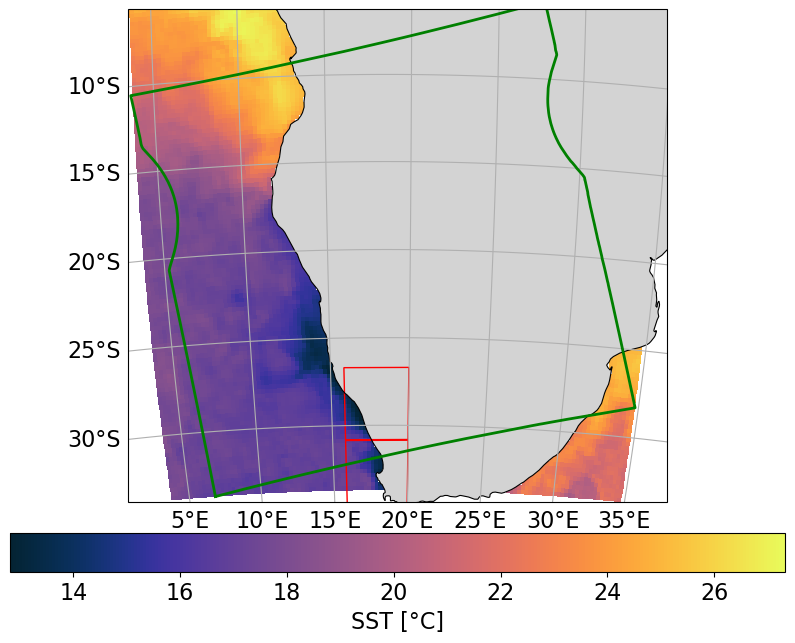

Figure saved to: ./figures/20251030/png/20251030T115343/20251030T115343_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


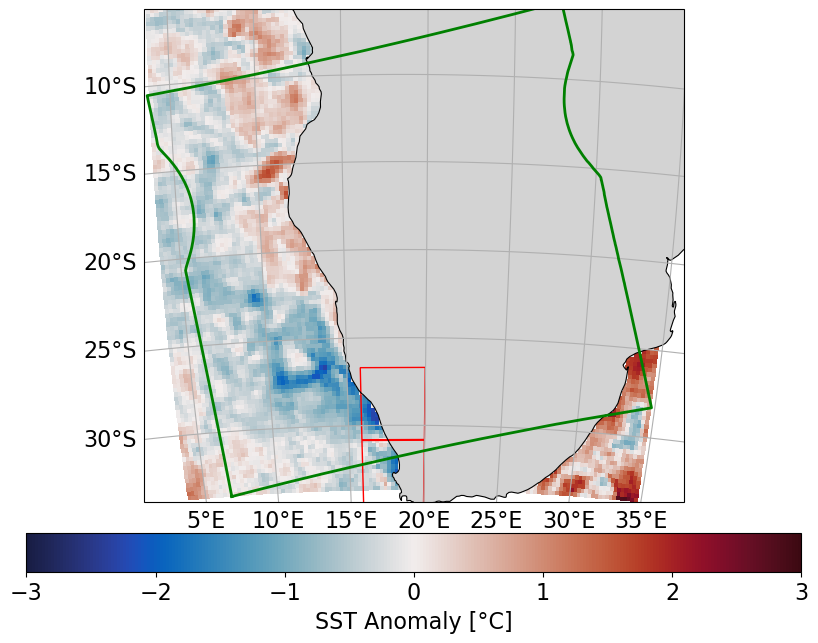

Figure saved to: ./figures/20251030/png/20251030T164342/20251030T164342_GHRSSTL4_SST_L2gran_bboxes.png


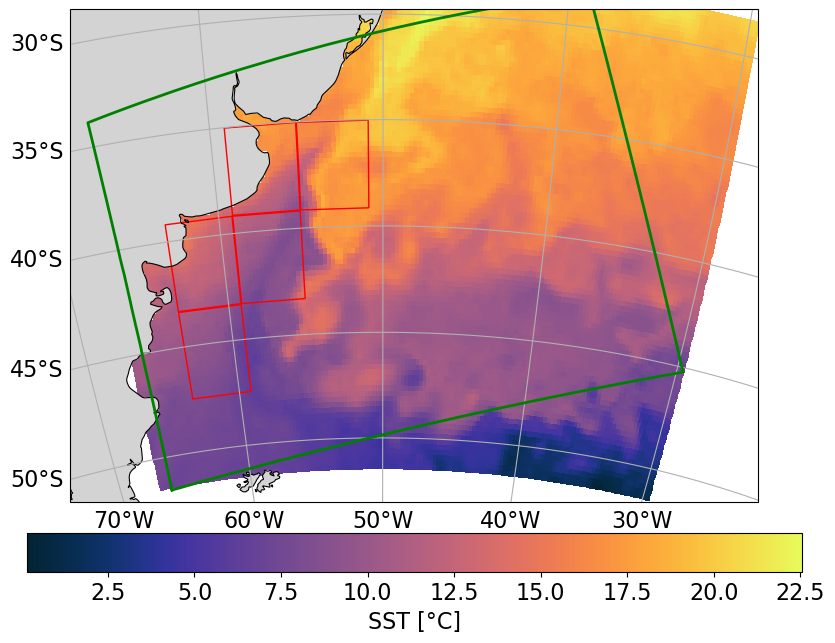

Figure saved to: ./figures/20251030/png/20251030T164342/20251030T164342_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


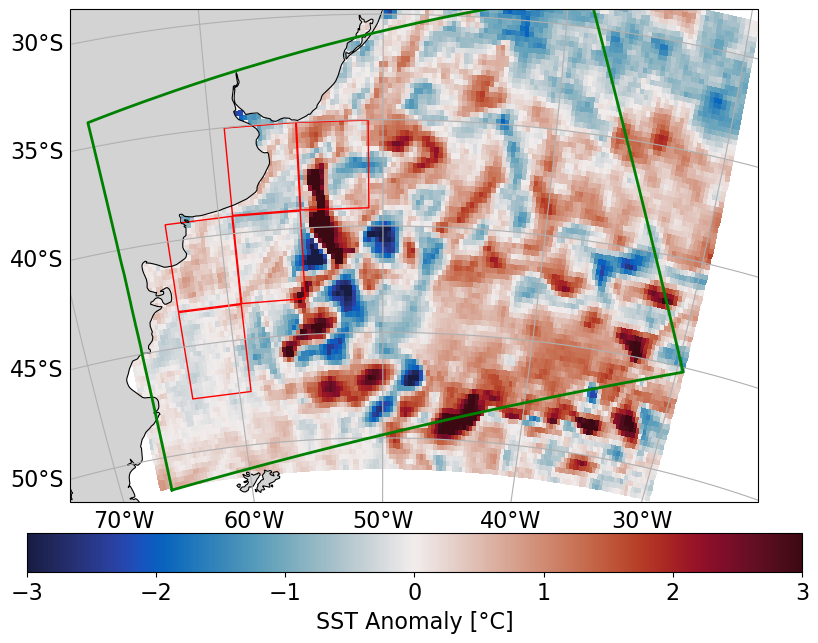

Figure saved to: ./figures/20251030/png/20251030T165842/20251030T165842_GHRSSTL4_SST_L2gran_bboxes.png


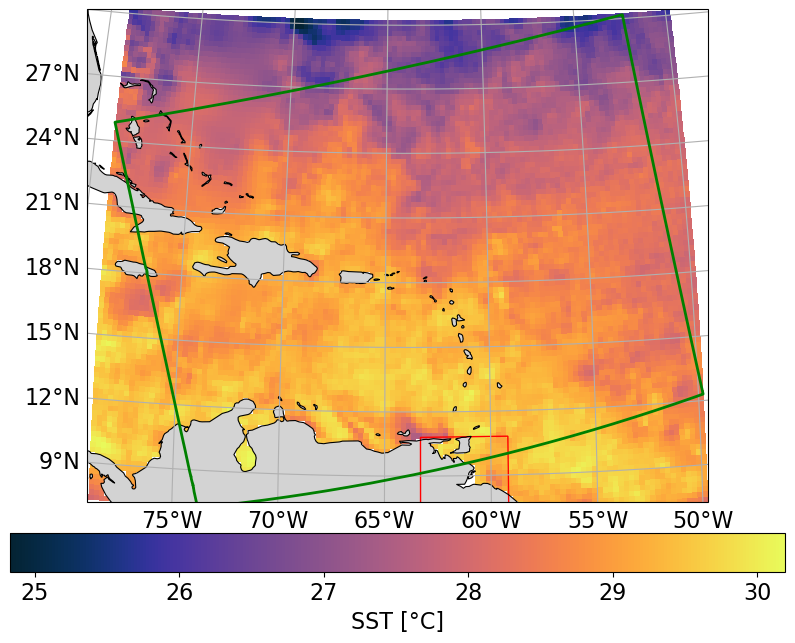

Figure saved to: ./figures/20251030/png/20251030T165842/20251030T165842_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


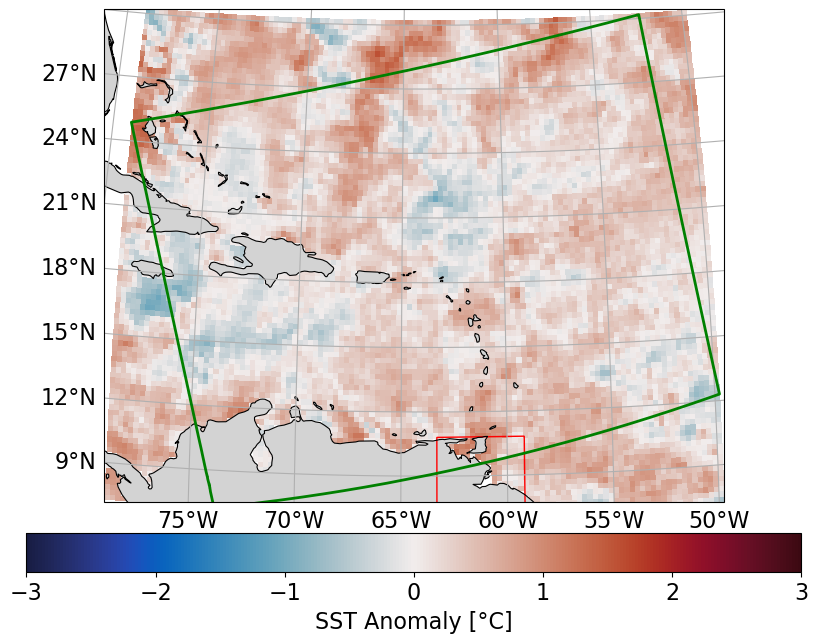

Figure saved to: ./figures/20251030/png/20251030T182202/20251030T182202_GHRSSTL4_SST_L2gran_bboxes.png


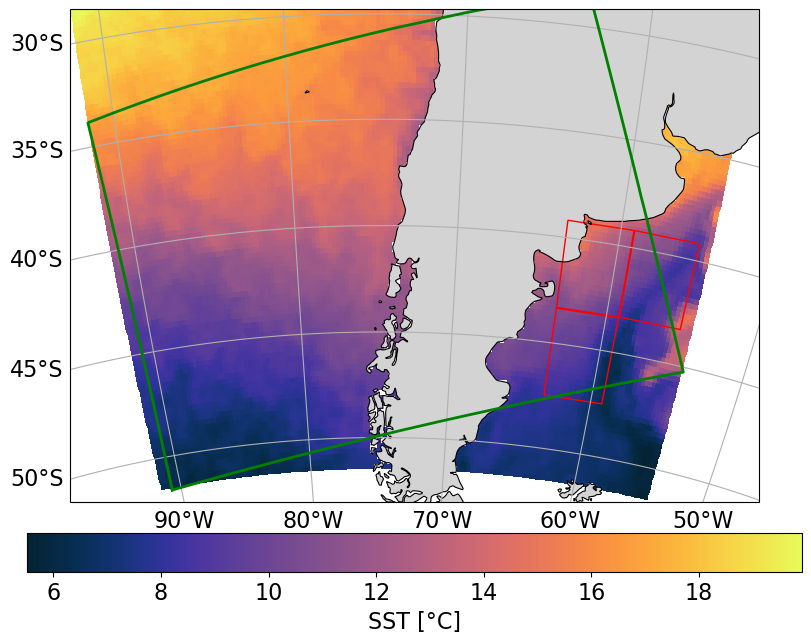

Figure saved to: ./figures/20251030/png/20251030T182202/20251030T182202_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png


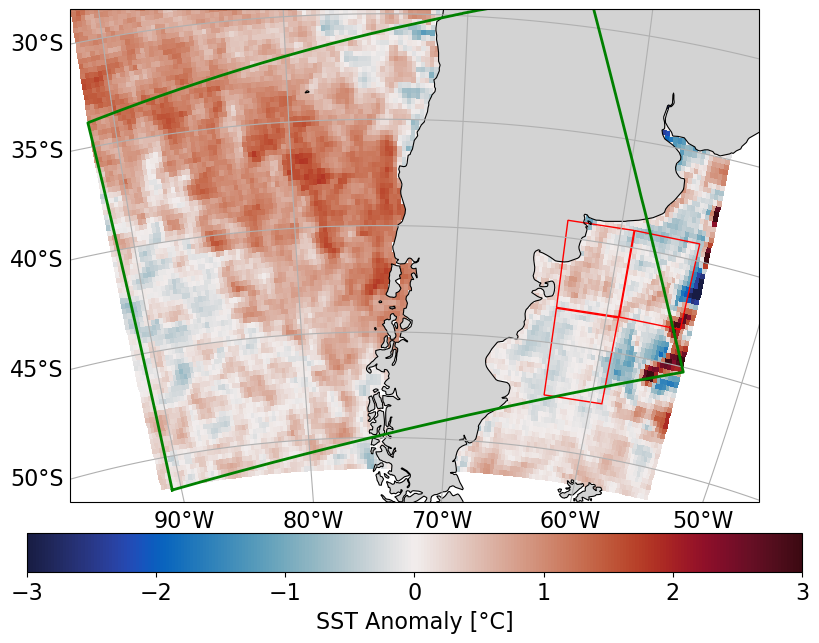

In [9]:
def plot_save_SST_overlay(l2_data_paths, datapath, savepath, tspan, l3_bboxes, granule_bbox_pixel_counts, show_fig=True, figsave=False, dpi=100):
    """
    Plot and optionally save SST and SST anomaly overlays on L2 granule extents with identified chl-a anomaly bounding boxes.

    This function retrieves GHRSST Level 4 SST data for a specified time span, then for each L2 granule,
    creates two maps: one showing absolute sea surface temperature (SST) and another showing SST anomalies from climatology data.
    Both maps include the L2 granule outline, associated L3 chl-a anomaly bounding boxes, and map context (land, ocean, coastlines).
    The function handles dateline crossing and restricts data to the spatial extent of each granule for efficiency.

    Parameters
    ----------
    l2_data_paths : list of tuple paths
        List of tuples, each containing file paths for a granule 
        (e.g.,  
        [('data/PACE_OCI.20250916T011442.L2.SFREFL.V3_1.NRT.nc', 'data/PACE_OCI.20250916T011442.L2.OC_BGC.V3_1.NRT.nc', 'data/PACE_OCI.20250916T011442.L2.OC_AOP.V3_1.NRT.nc'), 
        ('data/PACE_OCI.20250916T024802.L2.SFREFL.V3_1.NRT.nc', 'data/PACE_OCI.20250916T024802.L2.OC_BGC.V3_1.NRT.nc', 'data/PACE_OCI.20250916T024802.L2.OC_AOP.V3_1.NRT.nc')]
        ).
        The BGC file (typically at index 1) is used to extract coordinate information.
    datapath : str
        Local directory to save downloaded SST data files.
    savepath : str
        Directory to save generated figure PNG files. Subdirectories are created per granule date/time.
    tspan : tuple of str
        Time span for SST data search, e.g., ('2025-09-15', '2025-09-16'). Time components (HH:MM:SS)
        are automatically added as noon UTC.
    l3_bboxes : list of tuple
        List of bounding boxes (min_lon, min_lat, max_lon, max_lat) for overlay on plots.
    granule_bbox_pixel_counts : dict
        Dictionary mapping each granule path to a dict of {bbox_idx: valid_pixel_count}.
        Used to filter and highlight bounding boxes with sufficient valid data.
    show_fig : bool, optional
        If True, display figures interactively (default: True).
    figsave : bool, optional
        If True, save figures to disk in PNG format (default: False).
    dpi : int, optional
        Resolution of saved figures in dots per inch (default: 100).

    Returns
    -------
    None

    Notes
    -----
    - Data source: GHRSST Level 4 (MUR25-JPL-L4-GLOB-v04.2) at 0.25° resolution.
    - SST values are converted from Kelvin to Celsius.
    - SST anomaly range is fixed at -3 to +3°C for consistent visualization across granules.
    - The Orthographic projection is centered on each granule's mean longitude/latitude.
    - Granule outlines are split at dateline crossings (jumps >180°) for proper rendering.
    - Output filenames include granule date/time stamps extracted from the file path.

    Raises
    ------
    IndexError
        If the BGC file is not found in the path tuple (prints error and continues to next granule).

    Example
    -------
    >>> plot_save_SST_overlay(l2_data_paths_filt, './data/20250916/SST/', './figures/20250916/png/',
    ...                       ('2025-09-16', '2025-09-16'), l3_bboxes, granule_bbox_pixel_counts,
    ...                       show_fig=False, figsave=True, dpi=300)

    References
    ----------
    - PODAAC GHRSST dataset: https://podaac.jpl.nasa.gov/dataset/MUR-JPL-L4-GLOB-v4.1
    """
    # Status message and dataset information
    print(f"Generating {len(l2_data_paths)} SST and SST anomaly plots of identified L2 granules "
        "using 0.25 deg GHRSST Level 4 (MUR25-JPL-L4-GLOB-v04.2) dataset. "
        "For more information please see: "
        "https://podaac.jpl.nasa.gov/dataset/MUR-JPL-L4-GLOB-v4.1..."
    )

    # Download and open GHRSST SST data
    short_name = "MUR25-JPL-L4-GLOB-v04.2"

    # Add HH:MM:SS (set to noon UTC) to temporal span for earthaccess query
    tspan_with_time = (f"{tspan[0]} 12:00:00", f"{tspan[1]} 12:00:00")

    # Search and download SST data
    results = earthaccess.search_data(
        short_name=short_name,
        temporal=tspan_with_time,
    )

    sst_file_path = earthaccess.download(results, local_path=datapath)
    
    # Open and merge SST dataset
    sst_dt = xr.open_datatree(sst_file_path[0], decode_timedelta=True)
    sst_ds = xr.merge(sst_dt.to_dict().values())

    # Loop over each L2 granule
    for i, path in enumerate(l2_data_paths):
        try:
            # Extract index of BGC file (used for coordinates)
            BGC_idx = [j for j, p in enumerate(path) if 'BGC' in str(p)][0]
        except IndexError:
            print(f"Could not find BGC in path tuple: {path}")
            continue

        # Open and merge BGC dataset to extract granule coordinates
        dt = xr.open_datatree(path[BGC_idx], decode_timedelta=True)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        # Extract coordinate arrays
        lons = ds['longitude'].values
        lats = ds['latitude'].values
        min_lon = np.nanmin(lons)
        max_lon = np.nanmax(lons)
        min_lat = np.nanmin(lats)
        max_lat = np.nanmax(lats)
        
        # Handle dateline crossing by converting to 0-360 range
        if max_lon - min_lon > 180:
            lon_360 = lons % 360
            lon_ex_min = np.nanmin(lon_360)
            lon_ex_max = np.nanmax(lon_360)
        else:
            lon_ex_min = min_lon
            lon_ex_max = max_lon

        # Compute map center for Orthographic projection
        meanlon = float(np.nanmean(ds['longitude'].values))
        meanlat = float(np.nanmean(ds['latitude'].values))

        # ========== PLOT 1: ABSOLUTE SST ==========
        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.Orthographic(central_longitude=meanlon, central_latitude=meanlat)}
        )
        
        # Add map context features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor='white')
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
        ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
        ax.set_extent([lon_ex_min, lon_ex_max, min_lat, max_lat], crs=ccrs.PlateCarree())

        # Draw granule outline (clockwise from top-left, around edges, back to start)
        edge_lon = np.concatenate([lons[0, :], lons[1:, -1], lons[-1, ::-1], lons[-2::-1, 0]])
        edge_lat = np.concatenate([lats[0, :], lats[1:, -1], lats[-1, ::-1], lats[-2::-1, 0]])

        # Convert longitudes to [-180, 180] convention for PlateCarree projection
        edge_lon = ((edge_lon + 180) % 360) - 180
        
        # Split outline at dateline crossings (longitude jumps >180°) for proper visualization
        jump = np.abs(np.diff(edge_lon))
        split_idx = np.where(jump > 180)[0] + 1
        edge_lon_plot = np.split(edge_lon, split_idx) if split_idx.size > 0 else [edge_lon]
        edge_lat_plot = np.split(edge_lat, split_idx) if split_idx.size > 0 else [edge_lat]
        
        # Plot each segment of the granule outline
        for seg_lon, seg_lat in zip(edge_lon_plot, edge_lat_plot):
            ax.plot(seg_lon, seg_lat, color='green', linewidth=2, transform=ccrs.PlateCarree())

        # Restrict SST data to granule extent for efficiency
        dataarray_sst = sst_ds['analysed_sst'].squeeze('time') - 273.15  # Convert K to °C
        dataarray_sst = dataarray_sst.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))

        # Plot SST as pcolormesh overlay
        plot_sst = ax.pcolormesh(
            dataarray_sst["lon"],
            dataarray_sst["lat"],
            dataarray_sst,
            cmap=cmocean.cm.thermal,
            shading="auto",
            transform=ccrs.PlateCarree(),
            zorder=0
        )

        # Add colorbar
        cbar_sst = plt.colorbar(plot_sst, ax=ax, orientation='horizontal', pad=0.05)
        cbar_sst.set_label('SST [°C]')

        # Overlay L3 bounding boxes
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)

        # Save or display SST figure
        if figsave:
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(savepath, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f'{date_time}_GHRSSTL4_SST_L2gran_bboxes.png'
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")

        if show_fig:
            plt.show()
        plt.close()

        # ========== PLOT 2: SST ANOMALY ==========
        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.Orthographic(central_longitude=meanlon, central_latitude=meanlat)}
        )
        
        # Add map context features
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor='white')
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
        ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
        ax.set_extent([lon_ex_min, lon_ex_max, min_lat, max_lat], crs=ccrs.PlateCarree())

        # Draw granule outline (same as above)
        for seg_lon, seg_lat in zip(edge_lon_plot, edge_lat_plot):
            ax.plot(seg_lon, seg_lat, color='green', linewidth=2, transform=ccrs.PlateCarree())

        # Extract and restrict SST anomaly data to granule extent
        dataarray_anom = sst_ds['sst_anomaly'].squeeze('time')
        dataarray_anom = dataarray_anom.sel(lon=slice(min_lon, max_lon), lat=slice(min_lat, max_lat))

        # Plot SST anomaly with symmetric colorbar (balance colormap)
        plot_anom = ax.pcolormesh(
            dataarray_anom["lon"],
            dataarray_anom["lat"],
            dataarray_anom,
            cmap=cmocean.cm.balance,
            shading="auto",
            transform=ccrs.PlateCarree(),
            vmin=-3,
            vmax=3,
            zorder=0
        )

        # Add colorbar
        cbar_anom = plt.colorbar(plot_anom, ax=ax, orientation='horizontal', pad=0.05)
        cbar_anom.set_label('SST Anomaly [°C]')

        # Overlay L3 bounding boxes
        add_bboxes_to_plot(ax, path, l3_bboxes, granule_bbox_pixel_counts)

        # Save or display SST anomaly figure
        if figsave:
            basename = os.path.basename(path[0])
            parts = basename.split('.')
            date_time = parts[1] if len(parts) > 1 else f"granule_{i}"
            out_dir = os.path.join(savepath, date_time)
            os.makedirs(out_dir, exist_ok=True)
            fname = f'{date_time}_GHRSSTL4_SST_Anomaly_L2gran_bboxes.png'
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches='tight')
            print(f"Figure saved to: {os.path.join(out_dir, fname)}")

        if show_fig:
            plt.show()
        plt.close()

plot_save_SST_overlay(l2_data_paths_filt, sst_path , plot_path, tspan, l3_bboxes, granule_bbox_pixel_counts, show_fig=True, figsave=True)

## Delete Downloaded Files

In [17]:
# ========== STAGE 5: LOG AND DELETE DOWNLOADED FILES ==========
print("\n[Stage 5] Finalizing and cleaning up...")

def delete_downloaded_files(tspan, deleteflag=True):
    """
    Delete downloaded data files and subdirectories to free up space.

    Parameters
    ----------
    tspan : tuple of str
        Time span tuple, e.g., ('2025-10-30', '2025-10-30')
    deleteflag : bool, optional
        If True, delete subdirectories after logging (default: True)
    """
    date_str = tspan[0].replace('-', '')
    data_path = f'./data/{date_str}'

    # Discover all files in subdirectories
    l3_files_downloaded = []
    l2_files_downloaded = []
    
    if os.path.exists(data_path):
        for root, dirs, files in os.walk(data_path):
            for file in files:
                if file.endswith('.nc'):
                    # Classify files by directory name
                    if 'L3' in root:
                        l3_files_downloaded.append(file)
                    elif 'L2' in root:
                        l2_files_downloaded.append(file)

    # Create log file summarizing downloaded files
    log_filepath = os.path.join(data_path, 'downloaded_files_log.txt')
    with open(log_filepath, 'w') as log_file:
        log_file.write("Downloaded L3 Files:\n")
        for fname in l3_files_downloaded:
            log_file.write(f"{fname}\n")
        log_file.write(f"\nTotal L3 files: {len(l3_files_downloaded)}\n")
        log_file.write("\nDownloaded L2 Files:\n")
        for fname in l2_files_downloaded:
            log_file.write(f"{fname}\n")
        log_file.write(f"\nTotal L2 files: {len(l2_files_downloaded)}\n")
    print(f"Log of downloaded files saved to: {log_filepath}")

    # Delete downloaded data files and data directories to free up space
    delete_data = True  # Set to False to retain downloaded data
    if delete_data:
        for item in os.listdir(data_path):
            item_path = os.path.join(data_path, item)
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Deleted subdirectory: {item_path}")
        print(f"Cleaned up subdirectories in: {data_path}")
    else:
        print(f"Downloaded data retained at: {data_path}")

delete_downloaded_files(tspan, deleteflag=True)






[Stage 5] Finalizing and cleaning up...
Log of downloaded files saved to: ./data/20251030/downloaded_files_log.txt
Deleted subdirectory: ./data/20251030/L3
Deleted subdirectory: ./data/20251030/L2
Deleted subdirectory: ./data/20251030/SST
Cleaned up subdirectories in: ./data/20251030
